In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patheffects as path_effects
from matplotlib.colors import LinearSegmentedColormap
import os
import networkx as nx
import igraph as ig
import leidenalg as la
import glob

# import geopandas


In [235]:
# choose basa or GG
database = 'GG' # 'basa' or 'GG'

def get_functional_categories(database):
    if database == 'basa':
        basa_groups = pd.read_csv('./data/basa/basa_groups.csv')
        # make a community_int column with integers from 0 to number of unique communities - 1
        basa_groups['Community_int'] = basa_groups['Community'].astype('category').cat.codes
        basa_partition = basa_groups.set_index('Taxa').to_dict()['Community_int']

        basa_community_index = basa_groups.set_index('Community').to_dict()['Community_int']
        basa_community_index_T = {v: k for k, v in basa_community_index.items()}

        return basa_partition, basa_community_index, basa_community_index_T

    if database == 'GG':
        GG_groups = pd.read_csv('./data/GG/gg_groups.csv')
        GG_groups['Community_int'] = GG_groups['Community'].astype('category').cat.codes
        GG_partition = GG_groups.set_index('Taxa').to_dict()['Community_int']
        GG_community_index = GG_groups.set_index('Community').to_dict()['Community_int']
        GG_community_index_T = {v: k for k, v in GG_community_index.items()}

        return GG_partition, GG_community_index, GG_community_index_T

    if database == 'moossee':
        moossee_groups = pd.read_csv('./data/moossee/groups_moossee.csv')
        moossee_groups['Community_int'] = moossee_groups['Community'].astype('category').cat.codes
        moossee_partition = moossee_groups.set_index('Taxa').to_dict()['Community_int']
        moossee_community_index = moossee_groups.set_index('Community').to_dict()['Community_int']
        moossee_community_index_T = {v: k for k, v in moossee_community_index.items()}

        return moossee_partition, moossee_community_index, moossee_community_index_T
    
    if database == 'Burgäschisee':
        Burgäschisee_groups = pd.read_csv('./data/Burgäschisee/groups_Burgäschisee.csv')
        Burgäschisee_groups['Community_int'] = Burgäschisee_groups['Community'].astype('category').cat.codes
        Burgäschisee_partition = Burgäschisee_groups.set_index('Taxa').to_dict()['Community_int']
        Burgäschisee_community_index = Burgäschisee_groups.set_index('Community').to_dict()['Community_int']
        Burgäschisee_community_index_T = {v: k for k, v in Burgäschisee_community_index.items()}

        return Burgäschisee_partition, Burgäschisee_community_index, Burgäschisee_community_index_T
    
if database == 'basa':
    results = 'results/basa'
    data_species = './GAM_species/basa/species_fit_140_0.01.pkl'
    windows = [(0, 40), (20, 60), (40, 80), (60, 100), (80, 120), (100, 140)]
    windows = [(0, 51), (52, 85), (85, 140)]
    windows = [(0, 51), (51, 85), (85, 140)]
    # windows = [(51, 85)]

if database == 'GG':
    results = 'results/GG'
    data_species = './GAM_species/GG/species_fit_300_0.01.pkl'
    windows = [(0, 100), (50, 150), (100, 200), (150, 250), (200, 300)]
    windows = [(150, 199), (200, 249)]
    windows = [(0, 56)]
    windows = [(0, 56), (57, 149), (150, 249), (250, 300)]
    windows = [(0, 57), (57, 150), (150, 250), (250, 300)]

if database == 'moossee':
    results = 'results/moossee'
    data_species = './GAM_species/moossee/species_fit_815_0.01.pkl'
    windows = [(0, 149)]
    windows = [(0, 149), (149, 380), (380, 644), (644, 815)]

if database == 'Burgäschisee':
    results = 'results/Burgäschisee'
    data_species = './GAM_species/Burgäschisee/species_fit_723_0.01.pkl'
    windows = [(0, 149)]
    windows = [(0, 180), (180, 465), (465, 723)]

species_index = pd.read_pickle(f'./GAM_species/{database}/species_index.pkl')
species_index_T = pd.Series(species_index)
species_index_T = pd.Series(species_index_T.index, index = species_index_T.values)
species_index_T = species_index_T.to_dict()

if database == 'basa':
    species_index_non_aq = {k: v for k, v in species_index.items()}
    species_index_T_non_aq = {v: k for k, v in species_index_non_aq.items()}
    non_aq_species = list(species_index_non_aq.keys())
if database == 'GG':
    # ONLY NON AQUATIC SPECIES
    species_index_non_aq = {k: v for k, v in species_index.items()}
    species_index_T_non_aq = {v: k for k, v in species_index_non_aq.items()}
    non_aq_species = list(species_index_non_aq.keys())

if database == 'moossee':
    species_index_non_aq = {k: v for k, v in species_index.items()}
    species_index_T_non_aq = {v: k for k, v in species_index_non_aq.items()}
    non_aq_species = list(species_index_non_aq.keys())
if database == 'Burgäschisee':
    species_index_non_aq = {k: v for k, v in species_index.items()}
    species_index_T_non_aq = {v: k for k, v in species_index_non_aq.items()}
    non_aq_species = list(species_index_non_aq.keys())

abundances = pd.read_pickle(data_species)

custom_partition, custom_community_index, custom_community_index_T = get_functional_categories(database)

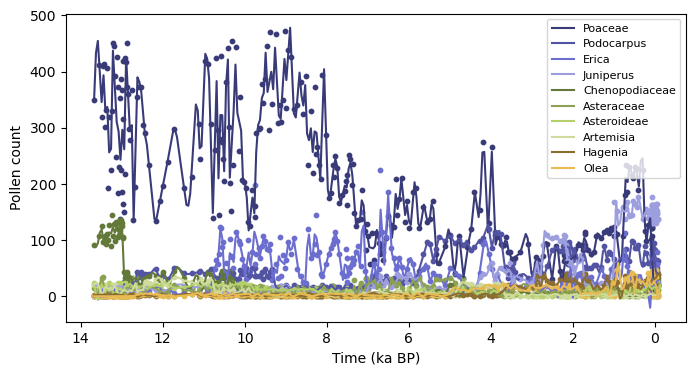

In [236]:
# plot the 10 species (all in the same axes) with highest total abundance over time
abundances_species = pd.DataFrame({k: v['y'] for k, v in abundances.items() if k in species_index_non_aq.keys()})

prev_abundances_species = pd.DataFrame({k: v['prev_y'] for k, v in abundances.items() if k in species_index_non_aq.keys()})
# sort by total abundance
abundances_species_sum = abundances_species.sum().sort_values(ascending=False)
top_10_species = abundances_species_sum.index[:10]

fig,ax = plt.subplots(figsize=(8, 4))

# get map
colors_sequence = plt.get_cmap('tab20b')(np.linspace(0, .5, len(top_10_species)))

for i,species in enumerate(top_10_species):
    ax.plot(-abundances[abundances.columns[1]]['x']/1000, abundances_species[species], color=colors_sequence[i], alpha=1, label=species)
    ax.scatter(-abundances[abundances.columns[1]]['prev_x']/1000, prev_abundances_species[species], color=colors_sequence[i], alpha=1, s=10)

# invert x axis
ax.invert_xaxis()
# ax.set_ylim(0,100)
ax.set_xlabel('Time (ka BP)')
ax.set_ylabel('Pollen count')
ax.legend(loc='upper right', fontsize=8)


In [237]:
import networkx as nx

def read_GC_network(causality_name):
    granger_causalities = []
    granger_causalities_p_values = []
    for idx,(start,end) in enumerate(windows):
        granger_causality = pd.read_pickle(f'{results}/{causality_name}/original_table_{start}-{end}.pkl')
        granger_causalities.append(granger_causality)

        granger_causality_p_values = pd.read_pickle(f'{results}/{causality_name}/bootstrapped_p_values_{start}-{end}.pkl')
        granger_causality_p_values[np.eye(granger_causality_p_values.shape[0], dtype=bool)] = np.nan
        granger_causalities_p_values.append(granger_causality_p_values)
    # L = 100
    graphs = []

    for idx,(start,end) in enumerate(windows):
        
        # for the TE p_values (p_values_list) or the gc p_values (granger_causalities_p_values)
        # adjacency = p_values_list[idx]
        adjacency = granger_causalities_p_values[idx]
        # remove na from the numpy array adjacency
        adjacency = np.nan_to_num(adjacency, nan=1.0)
        # ONLY NON AQUATIC SPECIES
        species_list = list(species_index_T_non_aq.keys())

        # adjacency_non_aq = adjacency[np.ix_(species_list, species_list)]
        # cut_value = np.sort(adjacency_non_aq.flatten())[L]

        cut_value = 0.05

        adjacency_pvalued = (adjacency <= cut_value).astype(int)
        adjacency = granger_causalities[idx] * adjacency_pvalued


        graph = nx.from_numpy_array(adjacency, create_using=nx.DiGraph, edge_attr='weight')
        # remove all nodes that are not in the non_aq_species list
        graph.remove_nodes_from([node for node in graph.nodes() if species_index_T[node] not in non_aq_species])


        valid_species = 0
        invalid_species_list = []
        pollen_threshold = 0.5 # if the series have less than 3 values above 0.5, we consider it as not present, and we remove the links to and from that species
        
        for node in graph.copy().nodes():
            species_name = species_index_T[node]
            if (abundances[species_name]['y'][start : end] > pollen_threshold).sum() < 2.5:
                
                # set granger_causalities to 0 and granger_causalities_p_values to 1
                granger_causalities[idx][:, node] = 0
                granger_causalities[idx][node, :] = 0
                granger_causalities_p_values[idx][:, node] = 1
                granger_causalities_p_values[idx][node, :] = 1

                graph.remove_node(node)
                invalid_species_list.append(species_name)

            else:
                valid_species = valid_species + 1

        print("Invalid species in window ", start, end, ": ", len(invalid_species_list))
        print("Invalid species in window ", start, end, ": ", invalid_species_list)
        print("Valid species in window ", start, end, ": ", valid_species)
        
        graphs.append(graph)
        print(cut_value, graph.number_of_edges())
        # currently it's just set to cut a certain value (p=0.05), so it's simple


    return granger_causalities, granger_causalities_p_values, graphs

In [238]:
def read_bootstrap_GC_networks(causality_name):
    bootstrap_dir = f'{results}/{causality_name}'

    original_table = []
    bootstrapped_p_values = []

    for idx,(start,end) in enumerate(windows):
        try:
            original_table.append(pd.read_pickle(f'{bootstrap_dir}/original_table_{start}-{end}.pkl'))
        except:
            print(f'No original p-values for window {start}-{end}')
            raise Exception;

        bootstrapped_p_values.append(np.zeros(original_table[0].shape))

        # get every bootstrap table for this window -> pattern is for example /table_0-50_bs*.pkl
        pattern = f'{bootstrap_dir}/bootstrap_tables/table_{start}-{end}_bs*.pkl'
        bootstrap_files = glob.glob(pattern)
        nbootstraps = len(bootstrap_files)
        print('Number of bootstraps: ', nbootstraps)
        # for b in range(nbootstraps):

        prob_lower = np.zeros(original_table[idx].shape)
        prob_higher = np.zeros(original_table[idx].shape)

        for bootstrap_file in bootstrap_files:
            try:
                bootstrap_table = pd.read_pickle(bootstrap_file)
            except:
                print('Error reading bootstrap file: ', bootstrap_file)
            # now we compare original_table and one bootstrap_table. for every element in the matrix
            # if original_p_values[i,j] > 0, then we count the bootstrap_table[i,j] >= original_p_values[i,j]
            # if original_p_values[i,j] < 0, then we count the bootstrap_table[i,j] <= original_p_values[i,j]
            
            prob_lower += (bootstrap_table < original_table[idx]).astype(int)
            prob_higher += (bootstrap_table > original_table[idx]).astype(int)

            #_______________________________________________________________
            # bootstrapped_p_values[idx] += 2 * ((bootstrap_table >= original_table[idx]) * (original_table[idx] >= average_bootstrap_table) + (bootstrap_table <= original_table[idx]) * (original_table[idx] < average_bootstrap_table)).astype(int)
            bootstrapped_p_values[idx] += (np.abs(bootstrap_table) >= np.abs(original_table[idx])).astype(int)
            # THESE ASSUME A SYMMETRIC DISTRIBUTION (or short tailed), WHICH MAY NOT BE THE CASE
            #_______________________________________________________________

        bootstrapped_p_values[idx] = bootstrapped_p_values[idx] / nbootstraps
        # bootstrapped_p_values[idx] = 2 * np.minimum(prob_lower, prob_higher) / nbootstraps
        
        # write the p-values to a file
        pd.to_pickle(bootstrapped_p_values[idx], f'{bootstrap_dir}/bootstrapped_p_values_{start}-{end}.pkl')
    return original_table, bootstrapped_p_values

In [239]:
causality_dir = 'bootstrap_conditional_GC_OLS'
lag = '_lag1'
cond = f'abundances_cond1{lag}'
# read_bootstrap_GC_networks(f'{causality_dir}/{cond}')
granger_causalities, granger_causalities_p_values, graphs = read_GC_network(f'{causality_dir}/{cond}')

Invalid species in window  0 57 :  40
Invalid species in window  0 57 :  ['Carduus', 'Polygonum', 'Tribulus', 'Hypericum', 'Myrsine', 'Rosa', 'Schefflera', 'Brucea', 'Iridaceae', 'Maytenus', 'Buxus', 'Psydrax', 'Celastraceae', 'Celtis', 'Ekebergia', 'Clematis', 'Allophylus', 'Commiphora', 'Cussonia', 'Dobera', 'Lannea', 'Macaranga', 'Jasminum', 'Rhus', 'Securinega', 'Teclea', 'Zanthoxylum', 'Euphorbia', 'Euphorbiacea', 'Phyllantus', 'Tamarindus', 'Alchornea', 'Asphodellus', 'Cerealia', 'Plantago', 'Planceolata', 'Rumex', 'Solanum', 'Urticaceae', 'Ricinus']
Valid species in window  0 57 :  42
0.05 70
Invalid species in window  57 150 :  21
Invalid species in window  57 150 :  ['Carduus', 'Polygonum', 'Rosa', 'Brucea', 'Buxus', 'Psydrax', 'Celastraceae', 'Ekebergia', 'Allophylus', 'Cussonia', 'Macaranga', 'Phyllantus', 'Tamarindus', 'Alchornea', 'Asphodellus', 'Cerealia', 'Plantago', 'Planceolata', 'Rumex', 'Solanum', 'Ricinus']
Valid species in window  57 150 :  61
0.05 111
Invalid spec

Window:  0 57
10 1
Galium Chenopodiaceae
Number of bootstraps:  4000
Coefficient =  2.673879241008015
Mean =  0.000962047427672509
Std =  5.707934102201872
N extremos =  2514
p-value =  0.6285


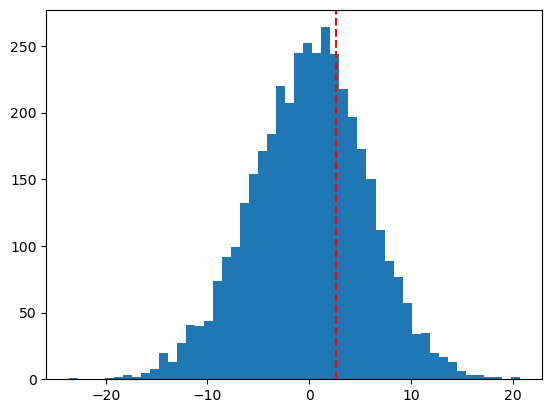

In [240]:
causality_name = 'bootstrap_conditional_GC_OLS/abundances_cond1_lag1'
bootstrap_dir = f'{results}/{causality_name}'

bootstrap_values_list = []

idx = 0
start,end = windows[idx]

# i = species_index_non_aq['Ulmus']
# j = species_index_non_aq['Poaceae']
i = 10
j = 1
print("Window: ", start, end)

print(i,j)
print(species_index_T_non_aq[i], species_index_T_non_aq[j])

try:
    original_table = pd.read_pickle(f'{bootstrap_dir}/original_table_{start}-{end}.pkl')
except:
    print(f'No original p-values for window {start}-{end}')
    raise Exception

bootstrapped_p_values = np.zeros(original_table.shape)

# get every bootstrap table for this window -> pattern is for example /table_0-50_bs*.pkl
pattern = f'{bootstrap_dir}/bootstrap_tables/table_{start}-{end}_bs*.pkl'
bootstrap_files = glob.glob(pattern)
nbootstraps = len(bootstrap_files)
print('Number of bootstraps: ', nbootstraps)
# for b in range(nbootstraps):
for bootstrap_file in bootstrap_files:
    try:
        bootstrap_table = pd.read_pickle(bootstrap_file)
    except:
        print('Error reading bootstrap file: ', bootstrap_file)
    bootstrapped_p_values += (np.abs(bootstrap_table) >= np.abs(original_table)).astype(int)
    bootstrap_values_list.append(bootstrap_table[i][j])
bootstrapped_p_values = bootstrapped_p_values / nbootstraps
bootstrap_values_list = np.array(bootstrap_values_list)
plt.hist(bootstrap_values_list.flatten(), bins=50)
plt.axvline(x=original_table[i][j], color='red', linestyle='--', label='Coefficient')

print("Coefficient = ", original_table[i][j])
print("Mean = ", np.mean(bootstrap_values_list.flatten()))
print("Std = ", np.std(bootstrap_values_list.flatten()))
# p-value
n_extremos = np.sum(np.abs(bootstrap_values_list.flatten()) >= np.abs(original_table[i][j]))
print("N extremos = ", n_extremos)
print("p-value = ",  (n_extremos) / (len(bootstrap_values_list.flatten())))

In [241]:
# set functional group as node attribute
for g in graphs:
    for node in g.nodes():
        species = species_index_T_non_aq[node]
        if species in custom_partition:
            g.nodes[node]['functional_group'] = custom_partition[species]
        else:
            g.nodes[node]['functional_group'] = -1

In [242]:
# calculate the number of positive and negative links within functional groups (just internal links) versus between functional groups
internal_links = []
external_links = []
total_links = []
for g in graphs:
    internal_pos_links = 0
    internal_neg_links = 0
    external_pos_links = 0
    external_neg_links = 0
    for u, v, data in g.edges(data=True):
        if g.nodes[u]['functional_group'] == g.nodes[v]['functional_group']:
            if data['weight'] > 0:
                internal_pos_links += 1
            elif data['weight'] < 0:
                internal_neg_links += 1
        else:
            if data['weight'] > 0:
                external_pos_links += 1
            elif data['weight'] < 0:
                external_neg_links += 1
    total_internal_links = internal_pos_links + internal_neg_links
    total_external_links = external_pos_links + external_neg_links

    percentage_negative_internal = internal_neg_links / total_internal_links if total_internal_links > 0 else 0
    percentage_negative_external = external_neg_links / total_external_links if total_external_links > 0 else 0
    percentage_total_links = (internal_neg_links + external_neg_links) / (total_internal_links + total_external_links)
    internal_links.append((percentage_negative_internal, total_internal_links))
    external_links.append((percentage_negative_external, total_external_links))
    total_links.append((percentage_total_links, total_internal_links + total_external_links))

print("Internal negatives: ", internal_links)
print("External negatives: ", external_links)
print("Total negatives: ", total_links)
print("\n")

Internal negatives:  [(0.47058823529411764, 17), (0.35, 20), (0.32142857142857145, 28), (0.2222222222222222, 45)]
External negatives:  [(0.5094339622641509, 53), (0.38461538461538464, 91), (0.47619047619047616, 105), (0.304635761589404, 151)]
Total negatives:  [(0.5, 70), (0.3783783783783784, 111), (0.44360902255639095, 133), (0.2857142857142857, 196)]




In [243]:
# GIANT COMPONENT
for graph in graphs:
    print([len(c) for c in sorted(nx.connected_components(graph.to_undirected()), key=len, reverse=True)])

[38, 2, 1, 1]
[60, 1]
[58, 2, 2, 1, 1, 1, 1]
[76, 1, 1]


In [244]:

def sequential_custom_generator():
    colors_list = ['forestgreen', 'royalblue', 'crimson', 'grey', 'purple', 'orange']

    colors_list = ["#006ba6","#0281d3","#0496ff","#ffbc42","#f69248","#ec674e","#d81159","#8f2d56"] # reds and blues
    colors_list = ["#f6ad02","#dbb314","#a1a94a","#88a559","#6ea067","#449d4c","#199a31","#0d841d"] # greens and yellows

    # for 9 colors instead of 8
    colors_list = ["#f6ad02","#dbb314","#a1a94a","#88a559","#6ea067","#449d4c","#199a31","#0d841d", "#0a662e"]

    index = 0
    # add randomness to which color we take each time (add a constant seed)
    np.random.seed(42)
    random_indices = np.random.permutation(len(colors_list))
    while True:
        yield mcolors.to_rgb(colors_list[index % len(colors_list)])
        index += 1

In [245]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
from collections import defaultdict
from networkx.drawing.nx_pydot import pydot_layout
import matplotlib.colors as mcolors

from lib.halfarrowpatch import *


def arc3_circle_center(posA, posB, rad):
    A, B = np.array(posA), np.array(posB)
    M = (A + B) * 0.5
    d = B - A
    L = np.linalg.norm(d)
    n = np.array([-d[1], d[0]]) / L
    h = rad * L * 0.5
    R = (L**2 / 4 + h**2) / (2 * h)
    C = M + n * (R - L**2 / (8 * h))
    return C, R

def rotate_point(p, center, angle):
    s, c = np.sin(angle), np.cos(angle)
    v = p - center
    return center + np.array([c*v[0] - s*v[1], s*v[0] + c*v[1]])

def add_curved_edge(ax, pos, u, v, color="black", weight=1.5, rad=0.3, angle=0, offset=0.0, node_radius_u=0.05, node_radius_v=0.05, arrowstyle='-|>', zorder=1, **kwargs):

    U = np.array(pos[u])
    V = np.array(pos[v])
    C, R = arc3_circle_center(np.array(pos[u]), np.array(pos[v]), rad)
    
    # Rotate endpoints
    U2 = rotate_point(U, C, np.deg2rad(angle))
    V2 = rotate_point(V, C, np.deg2rad(angle))

    x1, y1 = U2
    x2, y2 = V2

    # Compute direction and perpendicular vectors
    dx, dy = x2 - x1, y2 - y1
    dist = np.sqrt(dx**2 + dy**2)
    dir_vec = np.array([dx, dy]) / dist
    perp = np.array([-dy, dx]) / dist

    # Apply offset (for parallel edges)
    posA = np.array([x1, y1]) + perp * offset + dir_vec * np.sqrt(node_radius_u)
    posB = np.array([x2, y2]) + perp * offset - dir_vec * np.sqrt(node_radius_v)

    arrow = HalfArrowPatch(
        posA=posA,
        posB=posB,
        marker=arrowstyle,
        width=1,
        height=1,
        color=color,
        linewidth=weight,
        curvature=rad,
        zorder=zorder,
        arrow_linewidth=2.5*np.sqrt(weight),
        **kwargs
    )

    ax.add_patch(arrow)

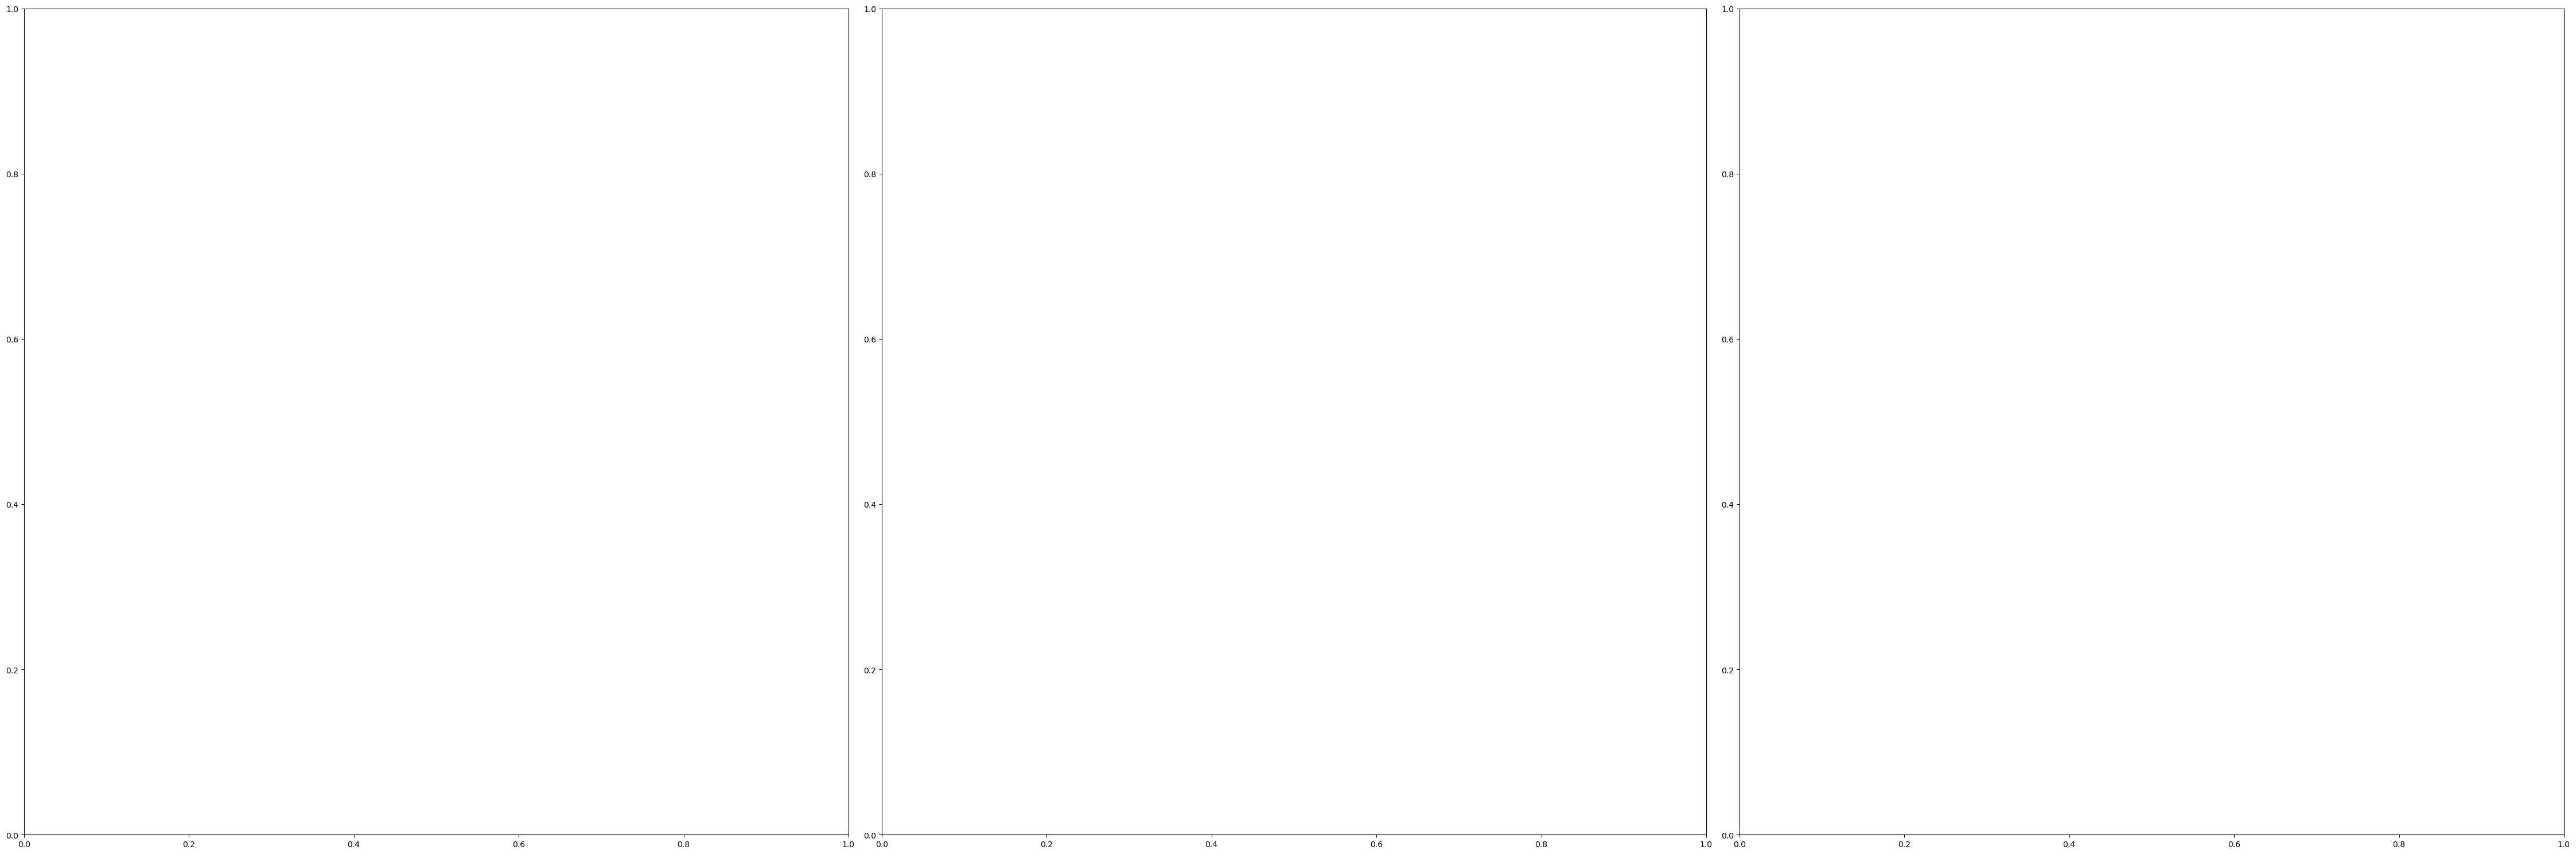

In [231]:
if database != 'basa':
    raise SystemExit("Different database")

# BASA DE LA MORA
fig, axes = plt.subplots(1,3,figsize=(45, 15))
fire_text = ['High fire', 'Low fire', 'Intermediate fire']
graphs_fg = []
for idx,(start,end) in enumerate(windows):
# group the nodes by functional group and plot the functional groups as nodes, with size proportional to number of species in group and edges' weights proportional to number of links between groups
    start, end = windows[idx]
    ax = axes[idx]
    graph = graphs[idx].copy()

    # create a new graph with functional groups as nodes
    G_fg = nx.MultiDiGraph()
    # count number of species in each functional group
    fg_counts = {}
    for node in graph.nodes():
        fg = graph.nodes[node]['functional_group']
        if fg not in fg_counts:
            fg_counts[fg] = 0
        fg_counts[fg] += 1
    for fg, count in fg_counts.items():
        G_fg.add_node(fg, size=count)
    # add edges between functional groups

    edge_weights = {}
    for u, v, data in graph.edges(data=True):
        fg_u = graph.nodes[u]['functional_group']
        fg_v = graph.nodes[v]['functional_group']
        # if fg_u != fg_v:
        if (fg_u, fg_v) not in edge_weights:
            edge_weights[(fg_u, fg_v)] = (0, 0)
        if data['weight'] > 0:
            edge_weights[(fg_u, fg_v)] = (edge_weights[(fg_u, fg_v)][0] + 1, edge_weights[(fg_u, fg_v)][1])
        elif data['weight'] < 0:
            edge_weights[(fg_u, fg_v)] = (edge_weights[(fg_u, fg_v)][0], edge_weights[(fg_u, fg_v)][1] + 1)
    # add edges to the graph
    for (fg_u, fg_v), weight in edge_weights.items():
        G_fg.add_edge(fg_u, fg_v, color = '#0F4C5C', weight=weight[0]*1.5,  sign='positive')#      np.sqrt(weight[0])*2.5)
        G_fg.add_edge(fg_u, fg_v, color = '#E36414',  weight=weight[1]*1.5, sign='negative')#      np.sqrt(weight[1]) *2.5)


    for u, v, key, weight in G_fg.copy().edges(data="weight", keys=True):
        # print(u, v, weight)
        if weight == 0:
            # print(f'Edge {u}->{v} has zero weight')
            G_fg.remove_edge(u,v,key)


    G = G_fg.copy()


    graphs_fg.append(G)
    continue
    # set initial positions where Grassland (node 0) is at the center, and the others around it in a circle

    labels = {  'temperate forest'     : 'Temperate\nforest',
                'pinewoods'             : 'Pinewoods',
                'shrubland'             : 'Shrubland',
                'riverine community'   : 'Riverine\ncommunity',
                'mediterranean'         : 'Mediterranean',
                'pastureland'           : 'Pastureland',
                'grassland'             : 'Grassland',
                'rocky community': 'Rocky\ncommunity'}
    
    order = {   'Temperate\nforest'    :  1,
                'Pinewoods'  : 2,
                'Shrubland' : 3,
                'Riverine\ncommunity'   : 4,
                'Mediterranean' : 5,
                'Rocky\ncommunity'  : 6,
                'Pastureland' :   7
                 }
    
    N = len(G.nodes())
    initial_pos = {custom_community_index['grassland']: np.array([0.0, 0.0])}

    angle_step = 2 * np.pi / len(order)
    
    for node in G.nodes():
        og_label = custom_community_index_T[node]
        label = labels[og_label]
        if og_label != 'grassland':
            angle = angle_step * (order[label]-1)
            initial_pos[node] = np.array([np.cos(angle), np.sin(angle)])

    # pos = nx.spring_layout(G, weight = 'weight', seed = 1, pos = initial_pos, iterations=4)
    # # write pos to numpy file
    # np.save(f'plots-tests/pos_basa.npy', pos)
    pos = np.load(f'plots-tests/pos_basa.npy', allow_pickle=True).item()



    node_sizes = {n:G.nodes[n]['size']*1000 for n in G.nodes()}
    edge_groups = defaultdict(list)
    for u, v, data in G.edges(data=True):
        edge_groups[(u, v)].append(data)

    max_total_weight = max(sum(edge['weight'] for edge in edges) for edges in edge_groups.values())

    renderer = ax.figure.canvas.get_renderer()
    print(renderer.points_to_pixels(1.0)/72)
    community_colors_gen = sequential_custom_generator()
    # first get one per label, then assign them by their index
    community_colors = np.array([next(community_colors_gen) for n in range(len(labels))])
    community_colors = {n:community_colors[n] for n in G.nodes()}

    node_size_scale = 1/600000
    scale = 0.00085  # converts linewidth to offset in data space
    scale = 0.00112  # converts linewidth to offset in data space


    for (u, v), edges in sorted(edge_groups.items(), key=lambda uv_edges: sum(edge['weight'] for edge in uv_edges[1])):
        n = len(edges)
        total_width = sum(edge["weight"] for edge in edges)
        alpha = min(1.1 - np.exp(-4*total_width/max_total_weight), 1)

        if n == 1:
            data = edges[0]
            add_curved_edge(ax, pos, u, v, color=data["color"], weight=data["weight"],
                            rad=0.25, offset=0.0, node_radius_u=node_sizes[u] * node_size_scale,
                            node_radius_v=node_sizes[v]*node_size_scale, zorder=-1,
                            alpha = alpha)
        elif n == 2:
            # Multiple edges draw as touching parallels
            # Compute offsets so they are side-by-side, centered on the main line
            cumulative = 0
            sorted_edges = sorted(edges, key=lambda e: e["weight"])  # sort by width (optional aesthetic)
            w_0 = sorted_edges[0]["weight"]
            w_1 = sorted_edges[1]["weight"]
            offset = (w_0+w_1 / 1.0) * scale

            # set seed
            np.random.seed(0)
            rad = np.random.uniform(0.15,0.25)
            add_curved_edge(ax, pos, u, v, color=sorted_edges[0]["color"], weight=w_0, angle=0,
                            rad=rad, offset=-offset - 0.02, node_radius_u=node_sizes[u]*node_size_scale,
                            node_radius_v=node_sizes[v]*node_size_scale, arrowstyle='|/', zorder = -1,
                            alpha = alpha)
            
            # draw a white node to cover up the tip of the first arrow before drawing the second arrow
            # circle = plt.Circle(pos[u], 1.25*np.sqrt(node_sizes[u]*node_size_scale), color='white', zorder = 0)
            # ax.add_artist(circle)

            add_curved_edge(ax, pos, u, v, color=sorted_edges[1]["color"], weight=w_1,
                            rad=rad, offset=-0.02, node_radius_u=node_sizes[u] * node_size_scale,
                            node_radius_v=node_sizes[v] * node_size_scale, arrowstyle='|\\', zorder=-1,
                            alpha = alpha)

    nx.draw_networkx_nodes(G, pos, node_color=[community_colors[node] for node in G.nodes()], ax=ax, node_size = [node_sizes[n] for n in G.nodes()],
                        edgecolors="#404040", linewidths=4)
    # custom_community_index_T
    
    # set offset to label positions
    label_pos = {n: pos[n] + np.array([0,np.sqrt(node_sizes[n])*0.001 + 0.11]) if pos[n][1] > 0.1 else
                    pos[n] + np.array([0,-np.sqrt(node_sizes[n])*0.001 - 0.1]) if pos[n][1] < -0.1 else 
                    pos[n] + np.array([0,np.sqrt(node_sizes[n])*0.001 + 0.1]) if pos[n][0] > 0.2 else
                    pos[n] + np.array([0,0.0]) for n in G.nodes()}
    
    texts = nx.draw_networkx_labels(G, pos = label_pos,
                                    ax=ax, labels={n:labels[custom_community_index_T[n]] for n in G.nodes()}, font_size = 35, font_color='black')
    
    # ADD WHITE BORDER TO THE TEXT ---------------------------------------------
    for text in texts.values():
            if text.get_text() == 'Grassland':
                text.set_path_effects([path_effects.Stroke(linewidth=6, foreground='white'),
                                path_effects.Normal()])
    # set limits to a square
    # ---------------------------------------------
    
    width = ax.get_xlim()[1] - ax.get_xlim()[0]
    height = ax.get_ylim()[1] - ax.get_ylim()[0]
    if width > height:
        plt.ylim(ax.get_ylim()[0] - (width - height) * 0.5, ax.get_ylim()[1] + (width - height) * 0.5)
    else:
        plt.xlim(ax.get_xlim()[0] - (height - width) * 0.5, ax.get_xlim()[1] + (height - width) * 0.5)
    # add some margin to the xlim and ylim
    margin = 0.18
    ax.set_ylim(ax.get_ylim()[0] - margin, ax.get_ylim()[1] + 2*margin)
    ax.set_xlim(ax.get_xlim()[0] - margin, ax.get_xlim()[1] + margin)
    print(ax.get_xlim(), ax.get_ylim())
    plt.axis("on")
    plt.tight_layout()


    # set title of the starting and ending years of the time window (set by abundances[species]['x'][start] and abundances[species]['x'][end])
    start_kabp = f'{-abundances[species_index_T_non_aq[0]]["x"][start]/1000 :.1f}'
    end_years = -abundances[species_index_T_non_aq[0]]["x"][end-1]
    end_kabp = f'{end_years/1000 :.1f} ka BP'
    print(end_years)
    if end_years < 0:
        start_kabp = f'{start_kabp} ka BP'
        end_kabp = 'present'
    ax.text(0.03, 0.95, f'{start_kabp} – {end_kabp}',
            transform=ax.transAxes, fontsize=38,
            verticalalignment='baseline', bbox=dict(boxstyle='round', facecolor='white', alpha=0.0))
    
    # ax.set_title(f'Period {idx+1}: {fire_text[idx]}', size = 36)
    ax.set_title(f'Period {idx+1}', size = 44, pad=22)
    

# --------------------------------------------------------------------------------------------------------------------------
    # now on the top right corner add the percentage of negative links (negative / negative+positive)
    negative_percentage = len([e for e in graph.edges(data=True) if e[2]['weight'] < 0]) / graph.number_of_edges()
    text_str =r'$f_{-}=' + f'{negative_percentage*100:.1f}' + r'\%$'
    ax.text(0.97, 0.95, text_str, fontsize=38,
            transform=ax.transAxes,
            va='baseline', horizontalalignment='right', clip_on=False)
# --------------------------------------------------------------------------------------------------------------------------

    rectangle_colors = ["#9b031a","#FB990E","#e35412"]
    import matplotlib.patches as patches
    bottom_rect = patches.Rectangle(
        (0, 1), width=1.0, height=-0.08,
        transform=ax.transAxes,
        facecolor=rectangle_colors[idx],
        zorder=-10,  # Ensure it sits behind the network and labels
        alpha=0.4,
        edgecolor='black',
        linewidth = 3
    )
    ax.add_patch(bottom_rect)


fig.tight_layout()
# fig.savefig(f'plots-tests/GC_functional_groups_{database}_{cond}.pdf')

In [180]:
# graphs as calculated above:
# calculate the total number of edges in each graph, and the number of positive and negative edges
total_edges = []
positive_edges = []
negative_edges = []
for idx,graph in enumerate(graphs_fg):
    total_edges.append([(e[0],e[1]) for e in graph.edges])
    positive_edges.append([(e[0],e[1]) for e in graph.edges(data=True) if e[2]['sign'] == 'positive'])
    negative_edges.append([(e[0],e[1]) for e in graph.edges(data=True) if e[2]['sign'] == 'negative'])
    print("period ", idx + 1)
    print("total unique edges: ", len(set(total_edges[-1])))
    print("auto loops: ", len(set([(e[0],e[1]) for e in graph.edges if e[0] == e[1]])))
    print("positive edges: ", len(positive_edges[-1]))
    print("negative edges: ", len(negative_edges[-1]), "\n")
    print("percentage negative edges: ", len(negative_edges[-1]) / len(total_edges[-1]) * 100, "\n")

period  1
total unique edges:  24
auto loops:  3
positive edges:  17
negative edges:  21 

percentage negative edges:  55.26315789473685 

period  2
total unique edges:  31
auto loops:  4
positive edges:  25
negative edges:  23 

percentage negative edges:  47.91666666666667 

period  3
total unique edges:  34
auto loops:  3
positive edges:  24
negative edges:  24 

percentage negative edges:  50.0 

period  4
total unique edges:  31
auto loops:  5
positive edges:  30
negative edges:  21 

percentage negative edges:  41.17647058823529 



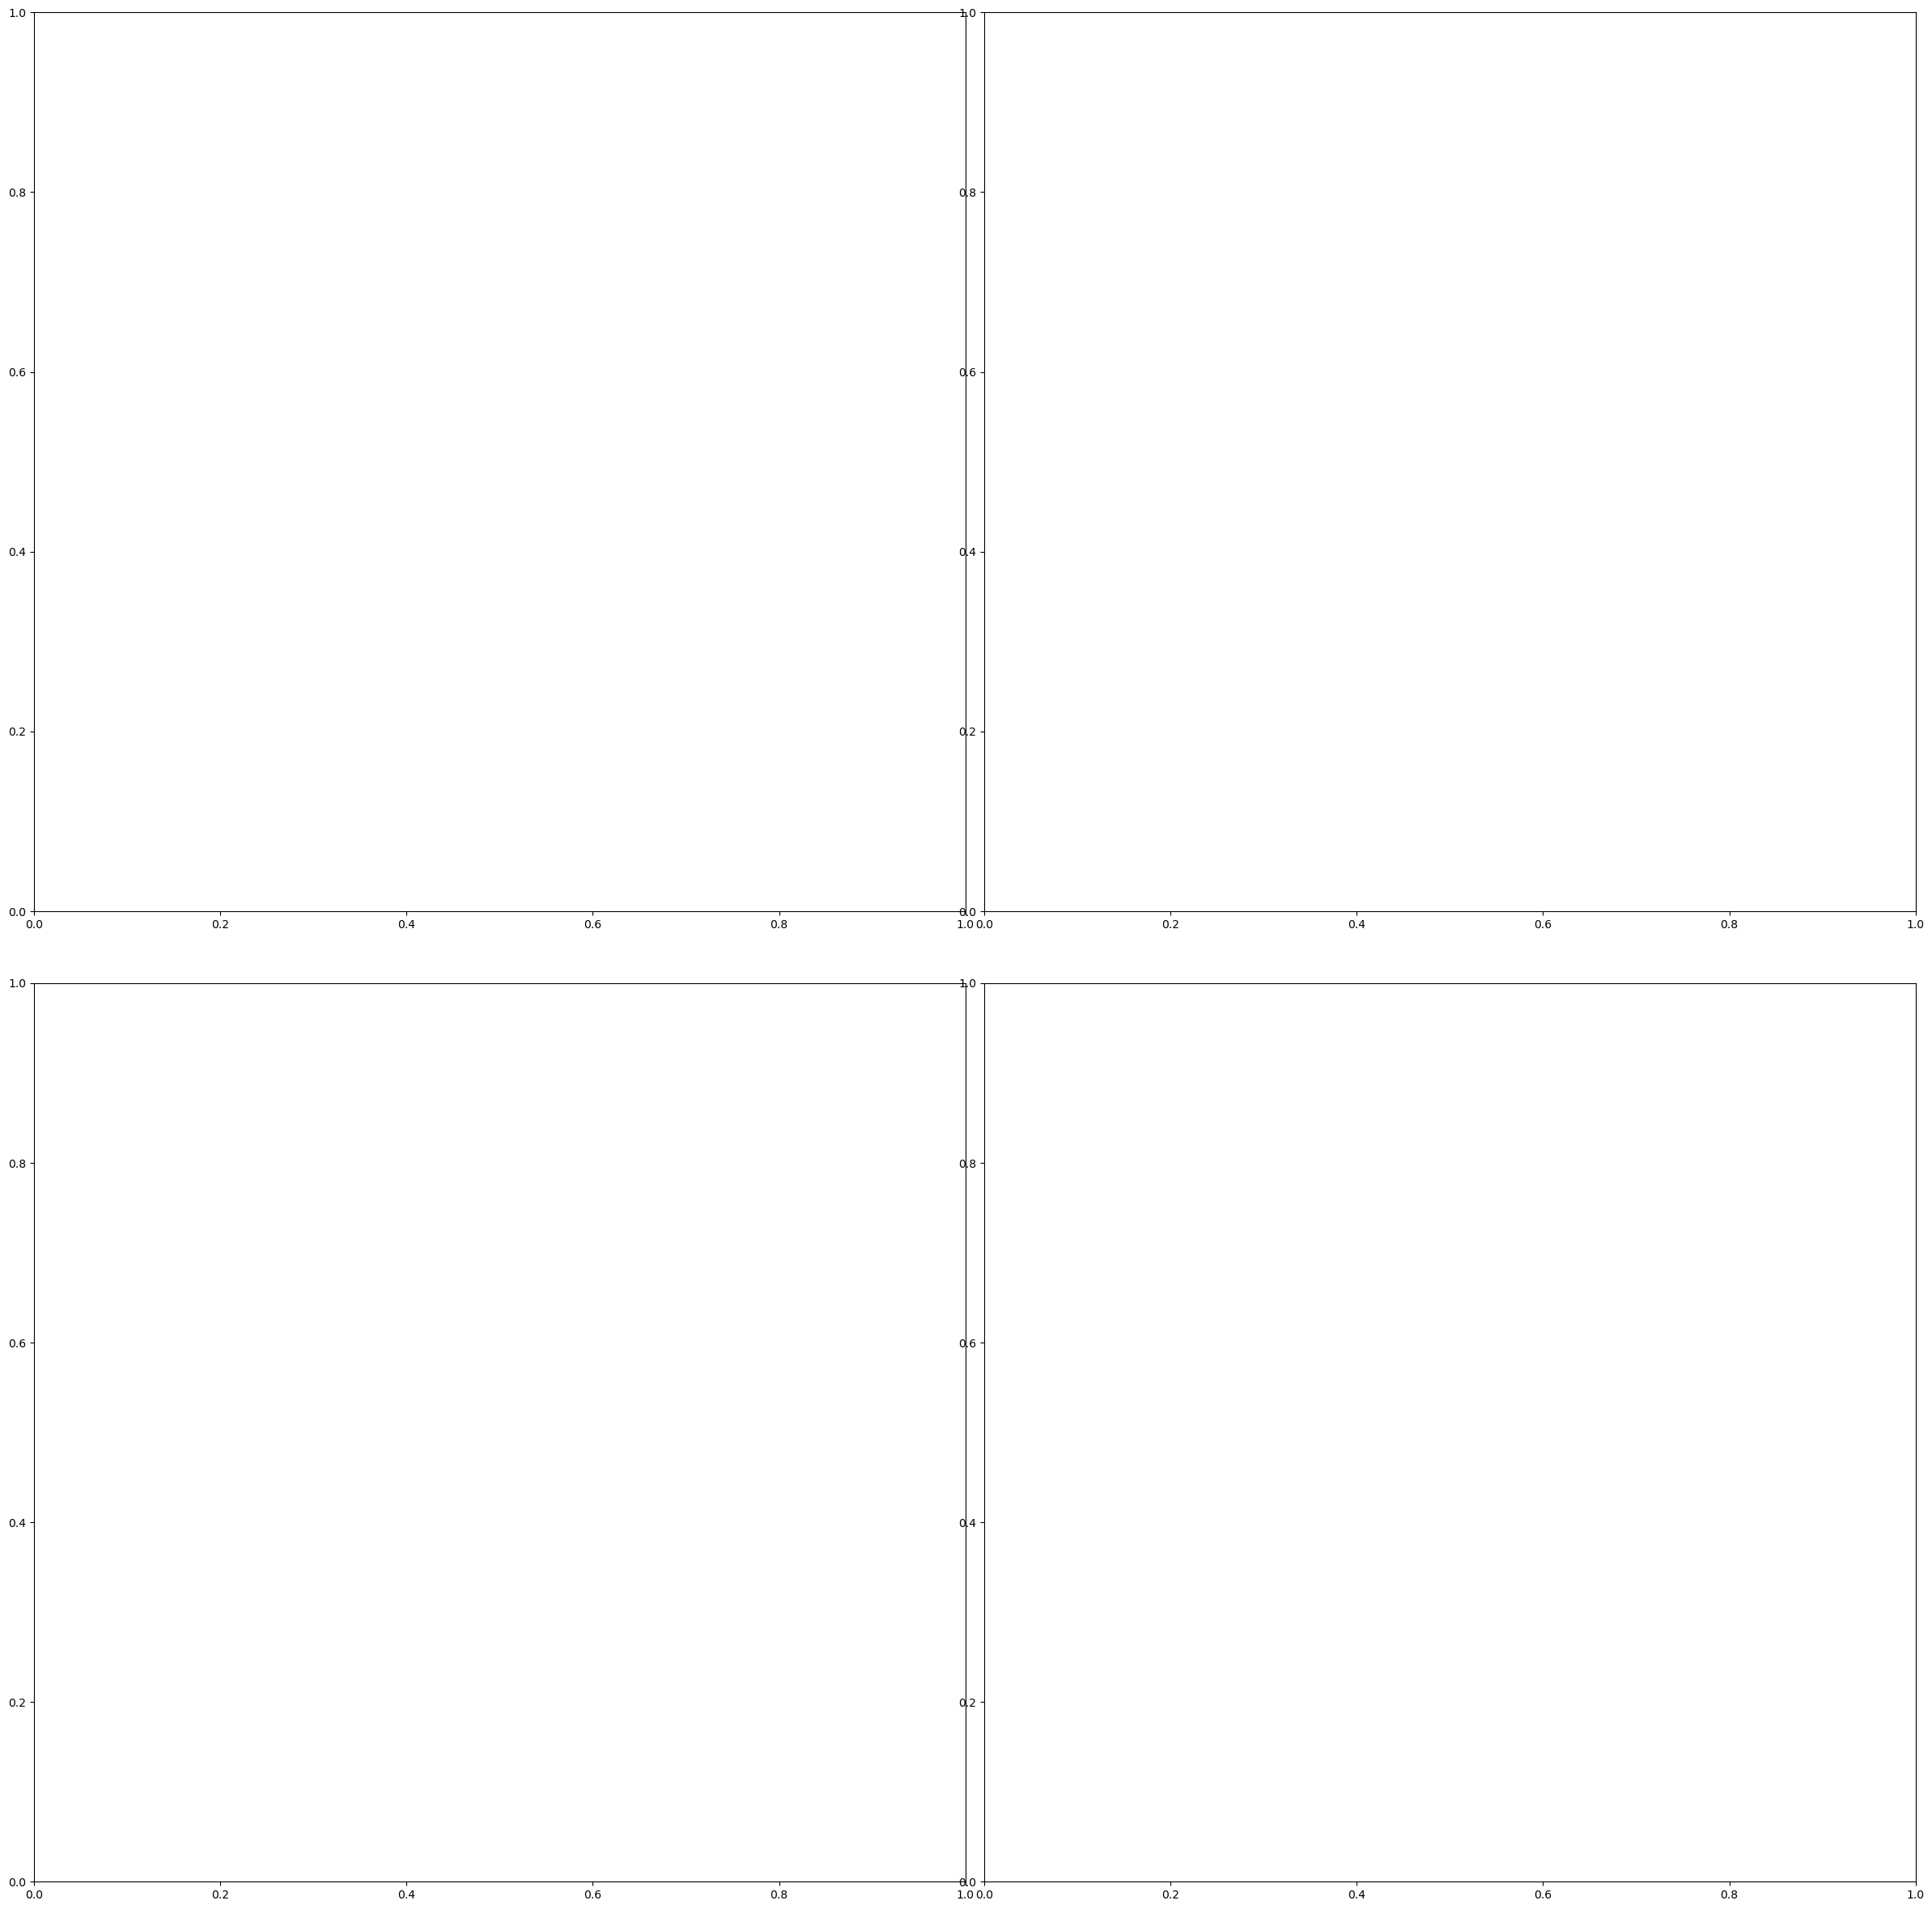

In [179]:
if database != 'GG':
    raise SystemExit("Different database")

graphs_fg = []

# GARBA GURACHA
fig, axes = plt.subplots(2,2,figsize=(30, 30))

for idx,(start,end) in enumerate(windows):
# group the nodes by functional group and plot the functional groups as nodes, with size proportional to number of species in group and edges' weights proportional to number of links between groups
    start, end = windows[idx]
    ax = axes.flatten()[idx]
    graph = graphs[idx].copy()

    # create a new graph with functional groups as nodes
    G_fg = nx.MultiDiGraph()
    # count number of species in each functional group
    fg_counts = {}
    for node in graph.nodes():
        fg = graph.nodes[node]['functional_group']
        if fg not in fg_counts:
            fg_counts[fg] = 0
        fg_counts[fg] += 1
    for fg, count in fg_counts.items():
        G_fg.add_node(fg, size=count)
    # add edges between functional groups
    edge_weights = {}
    for u, v, data in graph.edges(data=True):
        fg_u = graph.nodes[u]['functional_group']
        fg_v = graph.nodes[v]['functional_group']
        # if fg_u != fg_v:
        if (fg_u, fg_v) not in edge_weights:
            edge_weights[(fg_u, fg_v)] = (0, 0)
        if data['weight'] > 0:
            edge_weights[(fg_u, fg_v)] = (edge_weights[(fg_u, fg_v)][0] + 1, edge_weights[(fg_u, fg_v)][1])
        elif data['weight'] < 0:
            edge_weights[(fg_u, fg_v)] = (edge_weights[(fg_u, fg_v)][0], edge_weights[(fg_u, fg_v)][1] + 1)
    # add edges to the graph
    for (fg_u, fg_v), weight in edge_weights.items():
        G_fg.add_edge(fg_u, fg_v, color = '#0F4C5C', weight=weight[0]*2 , sign='positive')#      np.sqrt(weight[0])*2.5)
        G_fg.add_edge(fg_u, fg_v, color = '#E36414',  weight=weight[1]*2, sign='negative')#      np.sqrt(weight[1]) *2.5)


    for u, v, key, weight in G_fg.copy().edges(data="weight", keys=True):
        # print(u, v, weight)
        if weight == 0:
            # print(f'Edge {u}->{v} has zero weight')
            G_fg.remove_edge(u,v,key)


    G = G_fg.copy()
    graphs_fg.append(G)
    
    continue

    # set initial positions where Grassland (node 0) is at the center, and the others around it in a circle
    N = len(G.nodes())
    # angle_step = 2 * np.pi / (N - 1)
    
    # og labels vs new labels for plot
    labels = {  'Afroalpine'            : 'Afroalpine',
                'Ericaceous belt'       : 'Ericaceous\nbelt',
                'Forest belt'           : 'Forest\nbelt',
                'Grassland'             : 'Grassland',
                'Lower forest limit'    : 'Lower\nforest\nlimit',
                # 'Poaceae'               : 'Poaceae',
                'Ruderal'               : 'Ruderal',
                'Upper forest limit'    : 'Upper\nforest\nlimit'}

    initial_pos = {custom_community_index['Lower forest limit'] : np.array([0.0, 0.0])}

    order = {   'Grassland'    :   0,
                'Ruderal'  : 1,
                'Ericaceous\nbelt' : 2,
                'Afroalpine'   : 3,
                'Upper\nforest\nlimit' : 4,
                # 'Poaceae'  : 6,
                'Forest\nbelt' :   5
            }
    
    # for og_label, label in labels.items():
    angle_step = 2 * np.pi / len(order)

    for node in G.nodes():
        og_label = custom_community_index_T[node]
        label = labels[og_label]
        if og_label != 'Lower forest limit':
            angle = angle_step * (order[label] -1)
            initial_pos[node] = np.array([np.cos(angle), np.sin(angle)])

    
    pos = initial_pos.copy()
    # pos = nx.spring_layout(G, weight = 'weight', pos = initial_pos, iterations=1)
    # pos[5] = np.array([-0.85,-0.5])
    # write pos to numpy file
    # np.save(f'plots-tests/pos_GG.npy', pos)
    # pos = np.load(f'plots-tests/pos_GG.npy', allow_pickle=True).item()



    node_sizes = {n:G.nodes[n]['size']*1000 for n in G.nodes()}
    edge_groups = defaultdict(list)
    for u, v, data in G.edges(data=True):
        edge_groups[(u, v)].append(data)

    max_total_weight = max(sum(edge['weight'] for edge in edges) for edges in edge_groups.values())

    renderer = ax.figure.canvas.get_renderer()
    print(renderer.points_to_pixels(1.0)/72)
    community_colors_gen = sequential_custom_generator()
    community_colors = np.array([next(community_colors_gen) for n in range(len(labels))])
    community_colors = {n:community_colors[n] for n in G.nodes()}
    # swap colors for upper forest limit and afroalpine
    community_colors[custom_community_index['Lower forest limit']], community_colors[custom_community_index['Afroalpine']] = community_colors[custom_community_index['Afroalpine']], community_colors[custom_community_index['Lower forest limit']]

    node_size_scale = 1/600000
    scale = 0.00114  # converts linewidth to offset in data space


    for (u, v), edges in sorted(edge_groups.items(), key=lambda uv_edges: sum(edge['weight'] for edge in uv_edges[1])):
        n = len(edges)
        total_width = sum(edge["weight"] for edge in edges)
        alpha = min(1.1 - np.exp(-4*total_width/max_total_weight), 1)

        if n == 1:
            data = edges[0]
            add_curved_edge(ax, pos, u, v, color=data["color"], weight=data["weight"],
                            rad=0.25, offset=0.0, node_radius_u=node_sizes[u] * node_size_scale,
                            node_radius_v=node_sizes[v]*node_size_scale, zorder=-1,
                            alpha = alpha)
        elif n == 2:
            # Multiple edges draw as touching parallels
            # Compute offsets so they are side-by-side, centered on the main line
            cumulative = 0
            sorted_edges = sorted(edges, key=lambda e: e["weight"])  # sort by width (optional aesthetic)
            w_0 = sorted_edges[0]["weight"]
            w_1 = sorted_edges[1]["weight"]
            offset = (w_0+w_1 / 1.0) * scale

            # set seed
            np.random.seed(0)
            rad = np.random.uniform(0.15,0.25)
            add_curved_edge(ax, pos, u, v, color=sorted_edges[0]["color"], weight=w_0, angle=0,
                            rad=rad, offset=-offset - 0.03, node_radius_u=node_sizes[u]*node_size_scale,
                            node_radius_v=node_sizes[v]*node_size_scale, arrowstyle='|/', zorder = -1,
                            alpha = alpha)
            
            # draw a white node to cover up the tip of the first arrow before drawing the second arrow
            # circle = plt.Circle(pos[u], 1.25*np.sqrt(node_sizes[u]*node_size_scale), color='white', zorder = 0)
            # ax.add_artist(circle)

            add_curved_edge(ax, pos, u, v, color=sorted_edges[1]["color"], weight=w_1,
                            rad=rad, offset=-0.03, node_radius_u=node_sizes[u] * node_size_scale,
                            node_radius_v=node_sizes[v] * node_size_scale, arrowstyle='|\\', zorder=-1,
                            alpha = alpha)

    nx.draw_networkx_nodes(G, pos, node_color=[community_colors[node] for node in G.nodes()], ax=ax, node_size = [node_sizes[n] for n in G.nodes()],
                        edgecolors="black", linewidths=4)
    
    # set offset to label positions
                    
    label_pos = {n: pos[n] + np.array([0,0.0]) if labels[custom_community_index_T[n]] in ['Lower\nforest\nlimit'] else
                    pos[n] + np.array([0,-np.sqrt(node_sizes[n])*0.0016 - 0.065]) if labels[custom_community_index_T[n]] in ['Poaceae',
                                                                                                                            'Forest\nbelt',
                                                                                                                            'Grassland'] else
                    pos[n] + np.array([0,np.sqrt(node_sizes[n])*0.0016 + 0.12]) if labels[custom_community_index_T[n]] in ['Upper\nforest\nlimit'] else
                    pos[n] + np.array([0,np.sqrt(node_sizes[n])*0.0014 + 0.035]) if labels[custom_community_index_T[n]] in ['Afroalpine'] else
                    pos[n] + np.array([0,np.sqrt(node_sizes[n])*0.0017 + 0.066]) if labels[custom_community_index_T[n]] in ['Ericaceous\nbelt'] else
                    pos[n] + np.array([-0.01,np.sqrt(node_sizes[n])*0.0016 + 0.066]) if labels[custom_community_index_T[n]] in ['Ruderal'] else
                    pos[n] + np.array([0,np.sqrt(node_sizes[n])*0.0016 + 0.066])
                    for n in G.nodes()
                    }
    
    texts = nx.draw_networkx_labels(G, pos = label_pos,
                                    ax=ax, labels={n:labels[custom_community_index_T[n]] for n in G.nodes()}, font_size = 35, font_color='black')
    
    for text in texts.values():
            if text.get_text() == 'Lower\nforest\nlimit':
                text.set_path_effects([path_effects.Stroke(linewidth=6, foreground='white'),
                                path_effects.Normal()])


    # set limits to a square
    width = ax.get_xlim()[1] - ax.get_xlim()[0]
    height = ax.get_ylim()[1] - ax.get_ylim()[0]
    if width > height:
        plt.ylim(ax.get_ylim()[0] - (width - height) * 0.5, ax.get_ylim()[1] + (width - height) * 0.5)
    else:
        plt.xlim(ax.get_xlim()[0] - (height - width) * 0.5, ax.get_xlim()[1] + (height - width) * 0.5)
    # add some margin to the xlim and ylim
    margin = 0.2
    ax.set_ylim(ax.get_ylim()[0] - margin, ax.get_ylim()[1] + 1.4 * margin)
    ax.set_xlim(ax.get_xlim()[0] - margin, ax.get_xlim()[1] + margin)
    print(ax.get_xlim(), ax.get_ylim())
    ax.axis("on")
    plt.tight_layout()
    
    
    # set title of the starting and ending years of the time window (set by abundances[species]['x'][start] and abundances[species]['x'][end])
    start_kabp = f'{-abundances[species_index_T_non_aq[0]]["x"][start]/1000 :.1f}'
    end_years = -abundances[species_index_T_non_aq[0]]["x"][end-1]
    end_kabp = f'{end_years/1000 :.1f} ka BP'
    print(end_years)
    if end_years < 0:
        start_kabp = f'{start_kabp} ka BP'
        end_kabp = 'present'
    ax.text(0.03, 0.95, f'{start_kabp} – {end_kabp}',
            transform=ax.transAxes, fontsize=38,
            verticalalignment='baseline', bbox=dict(boxstyle='round', facecolor='white', alpha=0.0))
    
# --------------------------------------------------------------------------------------------------------------------------
    # now on the top right corner add the percentage of negative links (negative / negative+positive)
    negative_percentage = len([e for e in graph.edges(data=True) if e[2]['weight'] < 0]) / graph.number_of_edges()
    text_str =r'$f_{-}=' + f'{negative_percentage*100:.1f}' + r'\%$'
    ax.text(0.97, 0.95, text_str, fontsize=38,
            transform=ax.transAxes,
            va='baseline', horizontalalignment='right', clip_on=False)
# --------------------------------------------------------------------------------------------------------------------------
    ax.set_title(f'Period {idx+1}', size = 44, pad=24)


    rectangle_colors = ['#fb7923', '#9b031a', '#fb7923', '#9b031a']

    import matplotlib.patches as patches
    bottom_rect = patches.Rectangle(
        (0, 1), width=1.0, height=-0.08,
        transform=ax.transAxes,
        facecolor=rectangle_colors[idx],
        zorder=-10,  # Ensure it sits behind the network and labels
        alpha=0.4,
        edgecolor='black',
        linewidth = 3
    )
    ax.add_patch(bottom_rect)
# add some space between the subplots
plt.subplots_adjust(wspace=0.02, hspace=0.08)
    # plt.show()
fig.savefig(f'plots-tests/GC_functional_groups_{database}_{cond}.pdf', dpi=100, bbox_inches='tight')

In [119]:
if database != 'moossee':
    raise SystemExit("Different database")

# MOOSSEE
fig, axes = plt.subplots(2,2,figsize=(30, 30))
axes = axes.flatten()
for idx,(start,end) in enumerate(windows):
# group the nodes by functional group and plot the functional groups as nodes, with size proportional to number of species in group and edges' weights proportional to number of links between groups
    start, end = windows[idx]
    ax = axes[idx]
    graph = graphs[idx].copy()

    # create a new graph with functional groups as nodes
    G_fg = nx.MultiDiGraph()
    # count number of species in each functional group
    fg_counts = {}
    for node in graph.nodes():
        fg = graph.nodes[node]['functional_group']
        if fg not in fg_counts:
            fg_counts[fg] = 0
        fg_counts[fg] += 1
    # sort the dictionary by key
    fg_counts = dict(sorted(fg_counts.items(), key=lambda item: item[0]))
    for fg, count in fg_counts.items():
        G_fg.add_node(fg, size=count)
    # add edges between functional groups
    edge_weights = {}
    for u, v, data in graph.edges(data=True):
        fg_u = graph.nodes[u]['functional_group']
        fg_v = graph.nodes[v]['functional_group']
        if fg_u != fg_v:
            if (fg_u, fg_v) not in edge_weights:
                edge_weights[(fg_u, fg_v)] = (0, 0)
            if data['weight'] > 0:
                edge_weights[(fg_u, fg_v)] = (edge_weights[(fg_u, fg_v)][0] + 1, edge_weights[(fg_u, fg_v)][1])
            elif data['weight'] < 0:
                edge_weights[(fg_u, fg_v)] = (edge_weights[(fg_u, fg_v)][0], edge_weights[(fg_u, fg_v)][1] + 1)
    # add edges to the graph
    for (fg_u, fg_v), weight in edge_weights.items():
        G_fg.add_edge(fg_u, fg_v, color = '#0F4C5C', weight=weight[0]*1.5)#      np.sqrt(weight[0])*2.5)
        G_fg.add_edge(fg_u, fg_v, color = '#E36414',  weight=weight[1]*1.5)#      np.sqrt(weight[1]) *2.5)


    for u, v, key, weight in G_fg.copy().edges(data="weight", keys=True):
        # print(u, v, weight)
        if weight == 0:
            # print(f'Edge {u}->{v} has zero weight')
            G_fg.remove_edge(u,v,key)


    G = G_fg.copy()

    # set initial positions where Grassland (node 0) is at the center, and the others around it in a circle

    labels = {  0: 'anthropogenic',
                1: 'grassland',
                2: 'mediterranean',
                3: 'pastureland',
                4: 'pinewoods',
                5: 'riverine community',
                6: 'shrubland',
                7: 'subalpine forest',
                8: 'temperate forest'}
    
    order = {'anthropogenic' : 0,
            'grassland' : 1,
            'mediterranean' : 2,
            'pastureland' : 3,
            'pinewoods' : 4,
            'riverine community' : 5,
            'shrubland' : 6,
            'subalpine forest' : 7,
            'temperate forest' : 8 }
    
    N = len(G.nodes())
    initial_pos = {0: np.array([0.0, 0.0])}
    angle_step = 2 * np.pi / (N-1)
    for node, label in labels.items():
        # order nodes in a specific way
        # print(i, labels[node])
        if node != 0:
            angle = angle_step * (order[label]-2)
            initial_pos[node] = np.array([np.cos(angle), np.sin(angle)])

    pos = nx.spring_layout(G, weight = 'weight', seed = 1, pos = initial_pos, iterations=4)
    pos = initial_pos
    # pos[5] = np.array([-0.85,-0.5])
    # write pos to numpy file
    np.save(f'plots-tests/pos_moossee.npy', pos)
    pos = np.load(f'plots-tests/pos_moossee.npy', allow_pickle=True).item()



    node_sizes = {n:G.nodes[n]['size']*1000 for n in G.nodes()}
    edge_groups = defaultdict(list)
    for u, v, data in G.edges(data=True):
        edge_groups[(u, v)].append(data)

    max_total_weight = max(sum(edge['weight'] for edge in edges) for edges in edge_groups.values())

    renderer = ax.figure.canvas.get_renderer()
    print(renderer.points_to_pixels(1.0)/72)
    community_colors_gen = sequential_custom_generator()
    community_colors = {n: next(community_colors_gen) for n in G.nodes()}

    node_size_scale = 1/600000
    scale = 0.00112  # converts linewidth to offset in data space


    for (u, v), edges in sorted(edge_groups.items(), key=lambda uv_edges: sum(edge['weight'] for edge in uv_edges[1])):
        n = len(edges)
        total_width = sum(edge["weight"] for edge in edges)
        alpha = min(1.1 - np.exp(-4*total_width/max_total_weight), 1)

        if n == 1:
            data = edges[0]
            add_curved_edge(ax, pos, u, v, color=data["color"], weight=data["weight"],
                            rad=0.25, offset=0.0, node_radius_u=node_sizes[u] * node_size_scale,
                            node_radius_v=node_sizes[v]*node_size_scale, zorder=-1,
                            alpha = alpha)
        elif n == 2:
            # Multiple edges draw as touching parallels
            # Compute offsets so they are side-by-side, centered on the main line
            cumulative = 0
            sorted_edges = sorted(edges, key=lambda e: e["weight"])  # sort by width (optional aesthetic)
            w_0 = sorted_edges[0]["weight"]
            w_1 = sorted_edges[1]["weight"]
            offset = (w_0+w_1 / 1.0) * scale

            # set seed
            np.random.seed(0)
            rad = np.random.uniform(0.15,0.25)
            add_curved_edge(ax, pos, u, v, color=sorted_edges[0]["color"], weight=w_0, angle=0,
                            rad=rad, offset=-offset - 0.02, node_radius_u=node_sizes[u]*node_size_scale,
                            node_radius_v=node_sizes[v]*node_size_scale, arrowstyle='|/', zorder = -1,
                            alpha = alpha)
            
            # draw a white node to cover up the tip of the first arrow before drawing the second arrow
            # circle = plt.Circle(pos[u], 1.25*np.sqrt(node_sizes[u]*node_size_scale), color='white', zorder = 0)
            # ax.add_artist(circle)

            add_curved_edge(ax, pos, u, v, color=sorted_edges[1]["color"], weight=w_1,
                            rad=rad, offset=-0.02, node_radius_u=node_sizes[u] * node_size_scale,
                            node_radius_v=node_sizes[v] * node_size_scale, arrowstyle='|\\', zorder=-1,
                            alpha = alpha)

    nx.draw_networkx_nodes(G, pos, node_color=[community_colors[node] for node in G.nodes()], ax=ax, node_size = [node_sizes[n] for n in G.nodes()],
                        edgecolors="black", linewidths=4)
    # custom_community_index_T
    
    # set offset to label positions
    label_pos = {n: pos[n] + np.array([0,np.sqrt(node_sizes[n])*0.001 + 0.06]) if pos[n][1] > 0.1 else
                    pos[n] + np.array([0,-np.sqrt(node_sizes[n])*0.001 - 0.06]) if pos[n][1] < -0.1 else 
                    pos[n] + np.array([0,np.sqrt(node_sizes[n])*0.001 + 0.06]) if pos[n][0] > 0.2 else
                    pos[n] + np.array([0,0.0]) for n in G.nodes()}
    
    texts = nx.draw_networkx_labels(G, pos = label_pos,
                                    ax=ax, labels={n:labels[n] for n in G.nodes()}, font_size = 27, font_color='black')
    for text in texts.values():
            text.set_path_effects([path_effects.Stroke(linewidth=1.5, foreground='white'),
                            path_effects.Normal()])
    # set limits to a square
    width = ax.get_xlim()[1] - ax.get_xlim()[0]
    height = ax.get_ylim()[1] - ax.get_ylim()[0]
    if width > height:
        plt.ylim(ax.get_ylim()[0] - (width - height) * 0.5, ax.get_ylim()[1] + (width - height) * 0.5)
    else:
        plt.xlim(ax.get_xlim()[0] - (height - width) * 0.5, ax.get_xlim()[1] + (height - width) * 0.5)
    # add some margin to the xlim and ylim
    margin = 0.13
    ax.set_ylim(ax.get_ylim()[0] - margin, ax.get_ylim()[1] + margin)
    ax.set_xlim(ax.get_xlim()[0] - margin, ax.get_xlim()[1] + margin)
    print(ax.get_xlim(), ax.get_ylim())
    plt.axis("on")
    plt.tight_layout()
    # set title of the starting and ending years of the time window (set by abundances[species]['x'][start] and abundances[species]['x'][end])
    ax.text(0.03, 0.97, f'{-int(abundances[species_index_T_non_aq[0]]["x"][start])}a BP – {-int(abundances[species_index_T_non_aq[0]]["x"][end-1])}a BP',
            transform=ax.transAxes, fontsize=35,
            verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    # now on the top right corner add the percentage of negative links (negative / negative+positive)
    negative_percentage = len([e for e in graph.edges(data=True) if e[2]['weight'] < 0]) / graph.number_of_edges()
    ax.text(0.97, 0.97, f'Negative links: {negative_percentage*100:.1f}%',
            transform=ax.transAxes, fontsize=35,
            verticalalignment='top', horizontalalignment='right',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    # plt.show()
# fig.savefig(f'plots-tests/GC_functional_groups_{database}_{cond}_{lag}.pdf', dpi=300)

SystemExit: Different database

In [ ]:
if database != 'burgaschisee':
    raise SystemExit("Different database")


# BURGASCHISEE
fig, axes = plt.subplots(1,3,figsize=(45, 15))
axes = axes.flatten()
for idx,(start,end) in enumerate(windows):
# group the nodes by functional group and plot the functional groups as nodes, with size proportional to number of species in group and edges' weights proportional to number of links between groups
    start, end = windows[idx]
    ax = axes[idx]
    graph = graphs[idx].copy()

    # create a new graph with functional groups as nodes
    G_fg = nx.MultiDiGraph()
    # count number of species in each functional group
    fg_counts = {}
    for node in graph.nodes():
        fg = graph.nodes[node]['functional_group']
        if fg not in fg_counts:
            fg_counts[fg] = 0
        fg_counts[fg] += 1
    # sort the dictionary by key
    fg_counts = dict(sorted(fg_counts.items(), key=lambda item: item[0]))
    for fg, count in fg_counts.items():
        G_fg.add_node(fg, size=count)
    # add edges between functional groups
    edge_weights = {}
    for u, v, data in graph.edges(data=True):
        fg_u = graph.nodes[u]['functional_group']
        fg_v = graph.nodes[v]['functional_group']
        if fg_u != fg_v:
            if (fg_u, fg_v) not in edge_weights:
                edge_weights[(fg_u, fg_v)] = (0, 0)
            if data['weight'] > 0:
                edge_weights[(fg_u, fg_v)] = (edge_weights[(fg_u, fg_v)][0] + 1, edge_weights[(fg_u, fg_v)][1])
            elif data['weight'] < 0:
                edge_weights[(fg_u, fg_v)] = (edge_weights[(fg_u, fg_v)][0], edge_weights[(fg_u, fg_v)][1] + 1)
    # add edges to the graph
    for (fg_u, fg_v), weight in edge_weights.items():
        G_fg.add_edge(fg_u, fg_v, color = '#0F4C5C', weight=weight[0]*1.5)#      np.sqrt(weight[0])*2.5)
        G_fg.add_edge(fg_u, fg_v, color = '#E36414',  weight=weight[1]*1.5)#      np.sqrt(weight[1]) *2.5)


    for u, v, key, weight in G_fg.copy().edges(data="weight", keys=True):
        # print(u, v, weight)
        if weight == 0:
            # print(f'Edge {u}->{v} has zero weight')
            G_fg.remove_edge(u,v,key)


    G = G_fg.copy()

    # set initial positions where Grassland (node 0) is at the center, and the others around it in a circle

    labels = {  0: 'anthropogenic',
                1: 'grassland',
                2: 'mediterranean',
                3: 'pastureland',
                4: 'pinewoods',
                5: 'riverine community',
                6: 'shrubland',
                7: 'subalpine forest',
                8: 'temperate forest'}
    
    order = {'anthropogenic' : 0,
            'grassland' : 1,
            'mediterranean' : 2,
            'pastureland' : 3,
            'pinewoods' : 4,
            'riverine community' : 5,
            'shrubland' : 6,
            'subalpine forest' : 7,
            'temperate forest' : 8 }
    
    N = len(G.nodes())
    initial_pos = {0: np.array([0.0, 0.0])}
    angle_step = 2 * np.pi / (N)
    for node, label in labels.items():
        # order nodes in a specific way
        # print(i, labels[node])
        if node != 0:
            angle = angle_step * (order[label]-2)
            initial_pos[node] = np.array([np.cos(angle), np.sin(angle)])

    pos = nx.spring_layout(G, weight = 'weight', seed = 1, pos = initial_pos, iterations=4)
    pos = initial_pos
    # pos[5] = np.array([-0.85,-0.5])
    # write pos to numpy file
    np.save(f'plots-tests/pos_moossee.npy', pos)
    pos = np.load(f'plots-tests/pos_moossee.npy', allow_pickle=True).item()



    node_sizes = {n:G.nodes[n]['size']*1000 for n in G.nodes()}
    edge_groups = defaultdict(list)
    for u, v, data in G.edges(data=True):
        edge_groups[(u, v)].append(data)

    max_total_weight = max(sum(edge['weight'] for edge in edges) for edges in edge_groups.values())

    renderer = ax.figure.canvas.get_renderer()
    print(renderer.points_to_pixels(1.0)/72)
    community_colors_gen = sequential_custom_generator()
    community_colors = {n: next(community_colors_gen) for n in G.nodes()}

    node_size_scale = 1/600000
    scale = 0.00112  # converts linewidth to offset in data space


    for (u, v), edges in sorted(edge_groups.items(), key=lambda uv_edges: sum(edge['weight'] for edge in uv_edges[1])):
        n = len(edges)
        total_width = sum(edge["weight"] for edge in edges)
        alpha = min(1.1 - np.exp(-4*total_width/max_total_weight), 1)

        if n == 1:
            data = edges[0]
            add_curved_edge(ax, pos, u, v, color=data["color"], weight=data["weight"],
                            rad=0.25, offset=0.0, node_radius_u=node_sizes[u] * node_size_scale,
                            node_radius_v=node_sizes[v]*node_size_scale, zorder=-1,
                            alpha = alpha)
        elif n == 2:
            # Multiple edges draw as touching parallels
            # Compute offsets so they are side-by-side, centered on the main line
            cumulative = 0
            sorted_edges = sorted(edges, key=lambda e: e["weight"])  # sort by width (optional aesthetic)
            w_0 = sorted_edges[0]["weight"]
            w_1 = sorted_edges[1]["weight"]
            offset = (w_0+w_1 / 1.0) * scale

            # set seed
            np.random.seed(0)
            rad = np.random.uniform(0.15,0.25)
            add_curved_edge(ax, pos, u, v, color=sorted_edges[0]["color"], weight=w_0, angle=0,
                            rad=rad, offset=-offset - 0.02, node_radius_u=node_sizes[u]*node_size_scale,
                            node_radius_v=node_sizes[v]*node_size_scale, arrowstyle='|/', zorder = -1,
                            alpha = alpha)
            
            # draw a white node to cover up the tip of the first arrow before drawing the second arrow
            # circle = plt.Circle(pos[u], 1.25*np.sqrt(node_sizes[u]*node_size_scale), color='white', zorder = 0)
            # ax.add_artist(circle)

            add_curved_edge(ax, pos, u, v, color=sorted_edges[1]["color"], weight=w_1,
                            rad=rad, offset=-0.02, node_radius_u=node_sizes[u] * node_size_scale,
                            node_radius_v=node_sizes[v] * node_size_scale, arrowstyle='|\\', zorder=-1,
                            alpha = alpha)

    nx.draw_networkx_nodes(G, pos, node_color=[community_colors[node] for node in G.nodes()], ax=ax, node_size = [node_sizes[n] for n in G.nodes()],
                        edgecolors="black", linewidths=4)
    # custom_community_index_T
    
    # set offset to label positions
    label_pos = {n: pos[n] + np.array([0,np.sqrt(node_sizes[n])*0.001 + 0.06]) if pos[n][1] > 0.1 else
                    pos[n] + np.array([0,-np.sqrt(node_sizes[n])*0.001 - 0.06]) if pos[n][1] < -0.1 else 
                    pos[n] + np.array([0,np.sqrt(node_sizes[n])*0.001 + 0.06]) if pos[n][0] > 0.2 else
                    pos[n] + np.array([0,0.0]) for n in G.nodes()}
    
    texts = nx.draw_networkx_labels(G, pos = label_pos,
                                    ax=ax, labels={n:labels[n] for n in G.nodes()}, font_size = 27, font_color='black')
    for text in texts.values():
            text.set_path_effects([path_effects.Stroke(linewidth=1.5, foreground='white'),
                            path_effects.Normal()])
    # set limits to a square
    width = ax.get_xlim()[1] - ax.get_xlim()[0]
    height = ax.get_ylim()[1] - ax.get_ylim()[0]
    if width > height:
        plt.ylim(ax.get_ylim()[0] - (width - height) * 0.5, ax.get_ylim()[1] + (width - height) * 0.5)
    else:
        plt.xlim(ax.get_xlim()[0] - (height - width) * 0.5, ax.get_xlim()[1] + (height - width) * 0.5)
    # add some margin to the xlim and ylim
    margin = 0.13
    ax.set_ylim(ax.get_ylim()[0] - margin, ax.get_ylim()[1] + margin)
    ax.set_xlim(ax.get_xlim()[0] - margin, ax.get_xlim()[1] + margin)
    print(ax.get_xlim(), ax.get_ylim())
    plt.axis("on")
    plt.tight_layout()
    # set title of the starting and ending years of the time window (set by abundances[species]['x'][start] and abundances[species]['x'][end])
    ax.text(0.03, 0.97, f'{-int(abundances[species_index_T_non_aq[0]]["x"][start])}a BP – {-int(abundances[species_index_T_non_aq[0]]["x"][end-1])}a BP',
            transform=ax.transAxes, fontsize=35,
            verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    # now on the top right corner add the percentage of negative links (negative / negative+positive)
    negative_percentage = len([e for e in graph.edges(data=True) if e[2]['weight'] < 0]) / graph.number_of_edges()
    ax.text(0.97, 0.97, f'Negative links: {negative_percentage*100:.1f}%',
            transform=ax.transAxes, fontsize=35,
            verticalalignment='top', horizontalalignment='right',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    # plt.show()
fig.savefig(f'plots-tests/GC_functional_groups_{database}_{cond}.pdf', dpi=300)

SystemExit: Different database

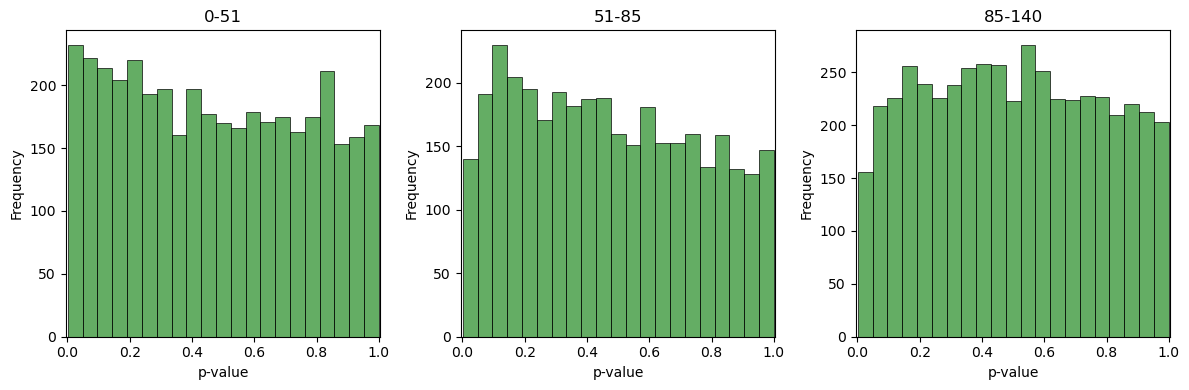

In [193]:
fig,axes = plt.subplots(1,len(windows),figsize=(4*len(windows), 4))
for idx in range(len(windows)):

    # every link that has a p-value of 1 in GC, put a p-value of 1 also in TE
    granger_causalities_p_values[idx][granger_causalities_p_values[idx] == 1.0] = np.nan
    # p_values_list[idx][granger_causalities_p_values[idx] == 1.0] = np.nan

    ax = axes.flatten()[idx]
    # ax.hist(p_values_list[idx].flatten(), bins = int(51), alpha=0.5, edgecolor='black', linewidth=0.25, color='blue', label='TE')
    granger_causality_pvalues = granger_causalities_p_values[idx].flatten()
    ax.hist(granger_causality_pvalues, bins = int(21), alpha=0.7, edgecolor='black', linewidth=0.7, color='forestgreen', label='GC')
    ax.set_xlabel('p-value')
    ax.set_ylabel('Frequency')
    # ax.legend()
    (start, end) = windows[idx]
    ax.set_title(f'{start}-{end}')
    ax.set_xlim(-0.005,1.005)
fig.set_tight_layout(True)
# fig.savefig(f'./plots_notes/p_values_GG.png', dpi=300)

In [246]:
def get_p_values_df(granger_causalities_p_values, granger_causalities, idx):
    # find out which species have the lowest p value
    p_values = granger_causalities_p_values[idx] # a numpy matrix of the pairs of species and the p-value of their granger causality
    causality_values = granger_causalities[idx] # a numpy matrix of the pairs of species and the granger causality value
    # find the pair with the lowest p-value
    
    # create a dataframe with all the pairs of species and their p-values
    rows_pvalues = []
    for i in range(p_values.shape[0]):
        for j in range(p_values.shape[1]):
            if not np.isnan(p_values[i, j]):
                try:
                    row = {'species_1': species_index_T_non_aq[i], 'species_2': species_index_T_non_aq[j], 'p_value': p_values[i, j], 'causality_value': causality_values[i, j]}
                    rows_pvalues.append(row)
                except KeyError:
                    # species not in the non_aq_species list
                    pass
    p_values_df = pd.DataFrame(rows_pvalues)
    p_values_df = p_values_df.sort_values(by='p_value', ascending=True)
    return p_values_df

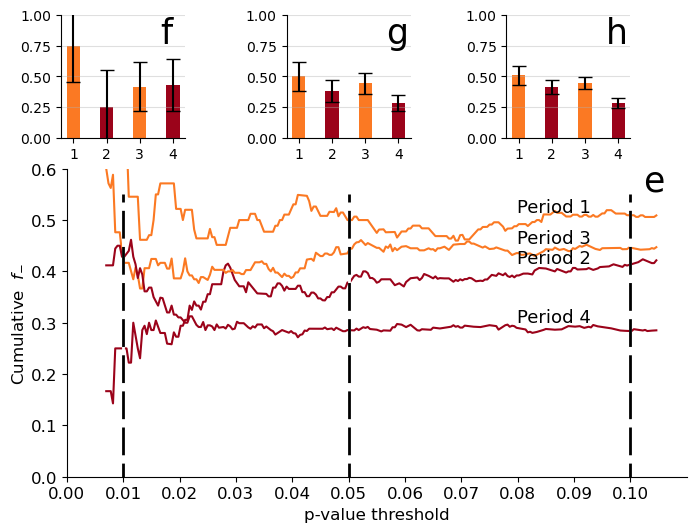

In [247]:

fig, ax = plt.subplots(figsize=(8, 4))
if database == 'basa':
    colors = ["#9b031a","#fb7923","#e35412"]
    colors = ["#9b031a","#FB990E","#e35412"]
elif database == 'GG':
    colors = ['#fb7923', '#9b031a', '#fb7923', '#9b031a']
elif database == 'moossee':
    colors = ['orange', 'red', 'orange', 'red']
elif database == 'Burgäschisee':
    colors = ['red', 'pink', 'red']


# margin of error
def MOE(p, n, z=1.96):
    return z * np.sqrt((p * (1 - p)) / n)


for idx in range(len(windows)):

    p_values_df = get_p_values_df(granger_causalities_p_values, granger_causalities, idx=idx)
    
    # make an array that is the 'causality_value' column of p_values_df in which
    # every value is the percentage of negative values up until that row
    negative_values = p_values_df['causality_value'].values < 0
    cumulative_negatives = np.cumsum(negative_values)
    total_counts = np.arange(1, len(p_values_df) + 1)
    p_values_df['negative_percentage'] = cumulative_negatives / total_counts

    # smooth it so that the line is not jagged, by setting uniform p-value thresholds
    p_value_array = np.arange(0.007, 0.105, 0.0004)
    negative_percentage_smooth = np.array(
        [p_values_df[p_values_df['p_value']<my_pvalue].iloc[-1]['negative_percentage'] for my_pvalue in p_value_array])

    # plt.plot(p_values_df['p_value'],p_values_df['negative_percentage'], color=colors[idx], label=f'Period {idx + 1}')
    plt.plot(p_value_array,negative_percentage_smooth, color=colors[idx])

    if database == 'basa':
        label_x_coord = 0.08
        label_y_coord = p_values_df[p_values_df['p_value']<label_x_coord].iloc[-1]['negative_percentage'] + 0.01
    elif database == 'GG':
        label_x_coord = 0.093
        label_y_coord = p_values_df[p_values_df['p_value']<label_x_coord].iloc[-1]['negative_percentage'] + 0.001

    ax.text(label_x_coord, label_y_coord, f'Period {idx + 1}', color='black', va='bottom', ha='right', fontsize=13)

# plot a vertical line on p-value = 0.05
ax.vlines([0.01, 0.05, 0.10], ymin=0, ymax=0.55, color='white', linewidth=2)
ax.vlines([0.01, 0.05, 0.10], ymin=0, ymax=0.55, color='black', linestyles=(5, (10, 3)), linewidth=2)

ax.set_xlim(0.0,0.11)
ax.set_ylim(0, 0.60)
ax.set_xticks(np.arange(0.00,0.108, 0.01))
ax.tick_params(axis='both', which='major', labelsize=12)

if database == 'basa':
    ax.text(0.93, 0.93, 'a', transform=ax.transAxes, fontsize=25)
    abc = ['b','c','d']
if database == 'GG':
    ax.text(0.93, 0.93, 'e', transform=ax.transAxes, fontsize=25)
    abc = ['f','g','h']
ax.set_xlabel('p-value threshold', fontsize=12)
ax.set_ylabel(r'Cumulative  $f_{-}$', fontsize=12)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)



data_to_axes = ax.transData + ax.transAxes.inverted()

for letter, p_value_threshold, ax_bounds, indicate_bounds in zip(abc, [0.01, 0.05, 0.10], 
                    [[data_to_axes.transform((0.01,0))[0] - 0.1, 1.1, 0.20, 0.4],
                     [data_to_axes.transform((0.05,0))[0] - 0.1, 1.1, 0.20, 0.4],
                     [data_to_axes.transform((0.10,0))[0] - 0.2, 1.1, 0.20, 0.4]],
                    [[0.01, 0.55, 0.0, 0.0], [0.05, 0.55, 0.0, 0.0], [0.1, 0.55, 0.0, 0.0]]):
    ax1 = ax.inset_axes(ax_bounds)

    # ax.indicate_inset(indicate_bounds, inset_ax=ax1, edgecolor="black", alpha=0.2, zorder=1)

    for idx in range(len(windows)):
        p_values_df = get_p_values_df(granger_causalities_p_values, granger_causalities, idx=idx)
        negative_values = p_values_df['causality_value'].values < 0
        cumulative_negatives = np.cumsum(negative_values)
        total_counts = np.arange(1, len(p_values_df) + 1)
        p_values_df['negative_percentage'] = cumulative_negatives / total_counts

        # get the negative percentage and moe at p-value = 0.05

        df_threshold = p_values_df[p_values_df['p_value'] <= p_value_threshold]
        if len(df_threshold) > 0:
            p_at_threshold = df_threshold['negative_percentage'].values[-1]
            n_at_threshold = len(df_threshold)
            moe = MOE(p_at_threshold, n_at_threshold)
            # bar plot
            ax1.bar(idx, p_at_threshold, color=colors[idx], capsize=6, alpha=1, width=0.4, align='center', edgecolor=None, linewidth=1)
            ax1.errorbar(idx, p_at_threshold, yerr=moe, fmt='', color='black', capsize=5)
        # ax1.set_xticks([])
        if database == 'basa':
            ax1.set_ylim(0, 0.8)
        if database == 'GG':
            ax1.set_ylim(0,1)
        ax1.grid(axis='y', alpha=0.4)
        ax1.spines['top'].set_visible(False)
        ax1.spines['right'].set_visible(False)
    # ax1.text(0.1, 1.1, letter, transform=ax1.transAxes, fontsize=18)
    ax1.set_xticks(range(len(windows)))
    ax1.set_xticklabels(range(1, len(windows)+1))
    ax1.tick_params(axis='both', which='major', labelsize=10)
    ax1.text(0.8, 0.77, letter, transform=ax1.transAxes, fontsize=25)



# fig.savefig(f'plots-tests/negative_percentage_vs_p_value_{database}.pdf', dpi=200, bbox_inches='tight')

## Degree distribution

/tmp/ipykernel_10287/1312044212.py:69: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(ax.get_yticklabels(), fontsize=11)
/tmp/ipykernel_10287/1312044212.py:80: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_yticklabels(ax2.get_yticklabels(), fontsize=11)


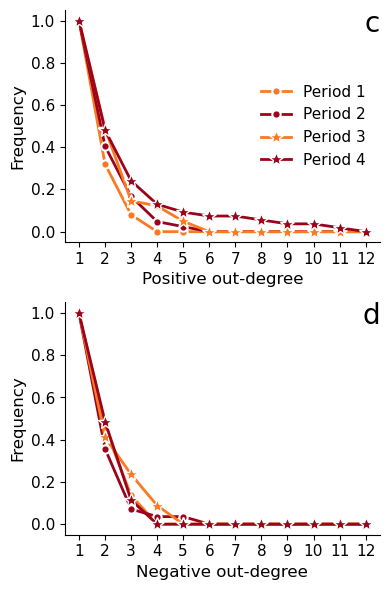

In [249]:
# calculate out-degree distributions

fig, axes = plt.subplots(2, 1, figsize=(4, 6))
degree_distributions = []

for idx, graph in enumerate(graphs):
    # Only take into account nodes with abundance higher than 0

    # out_degree = np.array([graphs[idx].out_degree(n) for n in graphs[idx].nodes() if (abundances[species_index_T_non_aq[n]]['y'][windows[idx][0]:windows[idx][1]].sum() > 0)])
    
    out_degree_pos_dict = {}
    out_degree_neg_dict = {}
    for u in graphs[idx].nodes():
        out_degree_pos_dict[u] = 0
        out_degree_neg_dict[u] = 0

    for u, v, d in graphs[idx].edges(data=True):
        #calculate out degree by adding
        if d['weight'] > 0:
            out_degree_pos_dict[u] += 1
        if d['weight'] < 0:
            out_degree_neg_dict[u] += 1
    out_degree_pos = np.array(list(out_degree_pos_dict.values()))
    out_degree_neg = np.array(list(out_degree_neg_dict.values()))

    # degree_distributions.append(out_degree)
    # plot the degree distributions

    ax = axes[0]
    ax2 = axes[1]

    bins = np.arange(0.5, 13.5, 1)
    bin_centers = 0.5 * (bins[:-1] + bins[1:])
    counts_pos, _ = np.histogram(out_degree_pos, bins=bins)
    counts_neg, _ = np.histogram(out_degree_neg, bins=bins)
    counts_pos = counts_pos / counts_pos.sum()
    counts_neg = counts_neg / counts_neg.sum()
    cum_probabilities_pos = np.cumsum(counts_pos[::-1])[::-1]
    cum_probabilities_neg = np.cumsum(counts_neg[::-1])[::-1]

    marker = '-o'
    markersize = 6
    markeredgewidth=1.5
    if (database == 'GG') & (idx in [2,3]):
        marker = '-*'
        markersize = 10
        markeredgewidth=1

    ax.plot(bin_centers, cum_probabilities_pos, marker, zorder=3, linewidth=2,
            color=colors[idx], label=f"Period {idx+1}",
            markersize=markersize,markeredgecolor='white', markeredgewidth=markeredgewidth)
    # legend with no frame
    ax.legend(frameon=False, fontsize=11)

    (start, end) = windows[idx]


    ax2.plot(bin_centers, cum_probabilities_neg, marker, zorder=3, linewidth=2,
            color=colors[idx], label=f"Period {idx+1}",
            markersize=markersize,markeredgecolor='white', markeredgewidth=markeredgewidth)


# ax.grid(axis='y', zorder=0, linestyle='--', alpha=1)
ax.set_xlabel('Positive out-degree', fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)

ax.set_xticks(np.arange(1, 13, 1))
ax.set_xticklabels(np.arange(1, 13, 1), rotation=0, fontsize=11)
ax.set_yticklabels(ax.get_yticklabels(), fontsize=11)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
    

# ax2.grid(axis='y', zorder=0, linestyle='--', alpha=1)
ax2.set_xlabel('Negative out-degree', fontsize=12)
ax2.set_ylabel('Frequency', fontsize=12)
ax2.set_xticks(np.arange(1, 13, 1))
ax2.set_xticklabels(np.arange(1, 13, 1), rotation=0, fontsize=11)
ax2.set_yticklabels(ax2.get_yticklabels(), fontsize=11)

ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)


if database == 'basa':
    abc = ['a','b']
if database == 'GG':
    abc = ['c', 'd']

ax.text(1,1, abc[0], fontsize=20,
        transform=ax.transAxes,
        va='top', horizontalalignment='right', clip_on=False)
ax2.text(1, 1, abc[1], fontsize=20,
    transform=ax2.transAxes,
    va='top', horizontalalignment='right', clip_on=False)

fig.set_tight_layout(True)
fig.savefig(f'./plots-tests/cgc_out_degree_distributions_firewindows_{database}.pdf', dpi=200)

## Overall temporality

70 111
70 133
70 196
111 70
111 133
111 196
133 70
133 111
133 196
196 70
196 111
196 133


/tmp/ipykernel_15999/1913631232.py:43: RuntimeWarning: invalid value encountered in scalar divide
  text = ax.text(j, i, f'{(temporalities[i, j]/random_temporalities[i,j]):.3f}', ha='center', va='center', color='w')


[Text(0, 0, 'Period 1'),
 Text(0, 1, 'Period 2'),
 Text(0, 2, 'Period 3'),
 Text(0, 3, 'Period 4')]

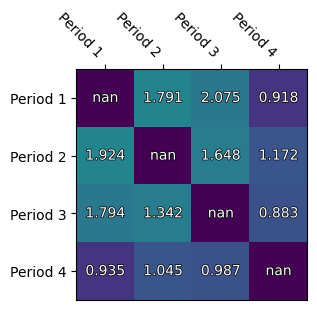

In [38]:
temporalities = np.zeros((len(graphs), len(graphs)))
random_temporalities = np.zeros((len(graphs), len(graphs)))
for i in range(0,len(graphs)):
    for j in range(0,len(graphs)):
        if i == j:
            continue
        edg1 = set(graphs[i].edges())
        edg2 = set(graphs[j].edges())

        #network temporality
        temporality = 1. - (1. - len(edg1 & edg2) / len(edg1 | edg2))
        edges_kept = len(edg1 & edg2)
        total_edges = len(edg1 | edg2)

        temporalities[i,j] = temporality

        # compare with random graphs

        n1 = graphs[i].number_of_nodes()
        n2 = graphs[j].number_of_nodes()
        l1 = graphs[i].number_of_edges()
        l2 = graphs[j].number_of_edges()
        
        print(l1, l2)
        n_rand_temp = 100
        for t in range(n_rand_temp):
            g1 = nx.gnm_random_graph(n1, l1, directed=True)
            g2 = nx.gnm_random_graph(n2, l2, directed=True)
            # calculate the temporality of the random graphs
            edg1 = set(g1.edges)
            edg2 = set(g2.edges)
            random_temporality = 1. - (1. - len(edg1 & edg2) / len(edg1 | edg2))
            random_temporalities[i,j] += random_temporality/n_rand_temp
            
fig, ax = plt.subplots(figsize=(3,3))

# plot a matrix with the temporalities
labels = [f'Period {i+1}' for i,window in enumerate(windows)]
im = ax.imshow(temporalities, cmap='viridis', vmin=0, vmax=0.05)

for i in range(temporalities.shape[0]):
    for j in range(temporalities.shape[1]):
        text = ax.text(j, i, f'{(temporalities[i, j]/random_temporalities[i,j]):.3f}', ha='center', va='center', color='w')
        text.set_path_effects([path_effects.Stroke(linewidth=1, foreground='black'), path_effects.Normal()])

ax.set_xticks(np.arange(len(labels)))
ax.set_yticks(np.arange(len(labels)))
ax.set_xticklabels(labels, rotation=-45, ha='right')
# place the xticklabels on top
ax.xaxis.set_ticks_position('top')
ax.set_yticklabels(labels)

# fig.savefig(f'./{results}/node_temporality_firewinkdows.png', dpi=300, bbox_inches='tight')

## Individual temporalities of nodes

236 151
1 - Temporality [0-51] -> [51-85]: 0.032   (mean random: 0.024, std: 0.009)
Edges kept: 12, Total edges: 375
151 161
1 - Temporality [51-85] -> [85-140]: 0.016   (mean random: 0.023, std: 0.009)
Edges kept: 5, Total edges: 307


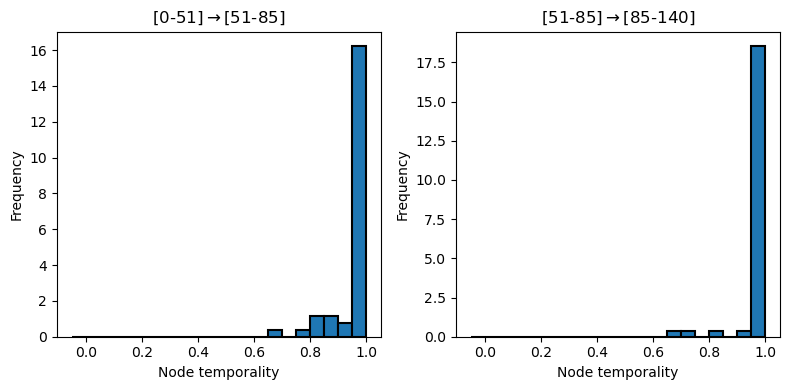

In [54]:
# individual temporalities of nodes
fig, axes = plt.subplots(1, len(windows)-1, figsize=(4*(len(windows)-1),4), layout='tight')

temporalities = pd.DataFrame(index = [species_index_T_non_aq[node] for node in graphs[idx].nodes()])

for i in range(0,len(graphs)-1):
    edg1 = set(graphs[i].edges)
    edg2 = set(graphs[i+1].edges)
    # edge temporality for each node: make a histogram of the number of edges that are present in both graphs for each node
    node_temporality = []
    for node in graphs[i].nodes():
        edg1_node = set(graphs[i].edges(node))
        try:
            edg2_node = set(graphs[i+1].edges(node))
        except: # if node is not in graphs[i+1] (got filtered), continue
            node_temporality.append(np.nan)
            continue
        if len(edg1_node | edg2_node) != 0:
            node_temporality.append(1 - len(edg1_node & edg2_node) / len(edg1_node | edg2_node))
        else:
            node_temporality.append(np.nan)

    # temporalities[i] = [node_temporality[i] for i, node in enumerate(graphs[idx].nodes())]
    
    # plot the histogram of node_temporality
    ax = axes.flatten()[i]
    ax.hist(node_temporality, bins=np.arange(-0.05, 1.05, 0.05), density=True,
            edgecolor='black', linewidth=1.5, histtype='bar', zorder=3)
    ax.set_xlabel('Node temporality')
    ax.set_ylabel('Frequency')
    ax.set_title(f'[{windows[i][0]}-{windows[i][1]}]' + r'$\rightarrow$' + f'[{windows[i+1][0]}-{windows[i+1][1]}]')

    #network temporality
    temporality = 1. - (1. - len(edg1 & edg2) / len(edg1 | edg2))
    edges_kept = len(edg1 & edg2)
    total_edges = len(edg1 | edg2)

    # compare with random graphs

    random_temporalities = np.zeros(100)  # Store temporality for 100 iterations
    n = graphs[i].number_of_nodes()
    l1 = graphs[i].number_of_edges()
    l2 = graphs[i+1].number_of_edges()
    print(l1, l2)
    for t in range(len(random_temporalities)):
        g1 = nx.gnm_random_graph(n, l1, directed=True)
        g2 = nx.gnm_random_graph(n, l2, directed=True)
        # calculate the temporality of the random graphs
        edg1 = set(g1.edges)
        edg2 = set(g2.edges)
        random_temporality = 1. - (1. - len(edg1 & edg2) / len(edg1 | edg2))
        random_temporalities[t] = random_temporality
        

    print(f'1 - Temporality [{windows[i][0]}-{windows[i][1]}] -> [{windows[i+1][0]}-{windows[i+1][1]}]: {temporality:.3f}' + 
          f'   (mean random: {random_temporalities.mean():.3f}, std: {random_temporalities.std():.3f})')
    print(f'Edges kept: {edges_kept}, Total edges: {total_edges}')

# fig.savefig(f'./{results}/node_temporality_firewinkdows.png', dpi=300, bbox_inches='tight')

## Distances between graphs (windows)

In [20]:
import networkx as nx
from collections import Counter
import hashlib

def weisfeiler_lehman_kernel(g1, g2, h=2):
    def initial_labeling(graph):
        return {node: str(graph.degree[node]) for node in graph.nodes()}
    
    def aggregate_labels(graph, labels):
        new_labels = {}
        for node in graph.nodes():
            neighbor_labels = sorted(labels[neighbor] for neighbor in graph.neighbors(node))
            long_label = labels[node] + "_" + "_".join(neighbor_labels)
            # Hash the label for uniqueness
            new_labels[node] = hashlib.md5(long_label.encode()).hexdigest()
        return new_labels

    def label_histogram(graph, h):
        labels = initial_labeling(graph)
        hist = Counter(labels.values())
        
        for i in range(h):
            labels = aggregate_labels(graph, labels)
            hist.update(labels.values())
        
        return hist

    hist1 = label_histogram(g1, h)
    hist2 = label_histogram(g2, h)

    # Compute kernel value as inner product (can also use other distances)
    kernel_value = sum(hist1[label] * hist2[label] for label in set(hist1) | set(hist2))
    return kernel_value

for idx in range(len(graphs)-1):
    similarity = weisfeiler_lehman_kernel(graphs[idx], graphs[idx+1], h=3)
    print(f"{windows[idx][0]}-{windows[idx][1]} to {windows[idx+1][0]}-{windows[idx+1][1]} similarity: {similarity:.3f}")

# similarity between similar random graphs
import random
def generate_random_graph(num_nodes, num_edges):
    G = nx.gnm_random_graph(num_nodes, num_edges, directed=True)
    return G

idx = 1
num_nodes = graphs[idx].number_of_nodes()
num_edges1 = graphs[idx].number_of_edges()
num_edges2 = graphs[idx+1].number_of_edges()
random_graphs1 = [generate_random_graph(num_nodes, num_edges1) for _ in range(10)]
random_graphs2 = [generate_random_graph(num_nodes, num_edges2) for _ in range(10)]
similarities = []

for idx in range(len(random_graphs1)):
    similarity = weisfeiler_lehman_kernel(random_graphs1[idx], random_graphs2[idx], h=3)
    similarities.append(similarity)
print(f"Average similarity between random graphs: {np.mean(similarities):.3f} ± {np.std(similarities):.3f}")

0-56 to 57-149 similarity: 2388.000
57-149 to 150-249 similarity: 1117.000
150-249 to 250-300 similarity: 604.000
Average similarity between random graphs: 779.600 ± 41.738


In [21]:
import graph_tool.all as gt
import matplotlib.colors as mcolors

# Function that returns a generator for sequential colormap colors
def sequential_color_generator(cmap_name='tab10'):
    cmap = plt.get_cmap(cmap_name)
    index = 0
    while True:
        yield cmap(index % cmap.N)
        index += 1
# Create a graph-tool Graph object from the networkx graph

def create_graph_tool_from_networkx(network):
    g = gt.Graph(directed=True)
    weight = g.new_edge_property("double")
    causality = g.new_edge_property("double")
    ecolor = g.new_edge_property("double")
    vlist = {}
    for node in network.nodes:
        #add vertex with the same index as in networkx (example: '32848242')
        vlist[node] = g.add_vertex()
        
    for edge in network.edges:
        e = g.add_edge(vlist[edge[0]], vlist[edge[1]])
        causality[e] = network.edges[edge]['weight']
        if causality[e] >= 0:
            ecolor[e] = 1
            weight[e] = np.sqrt(causality[e])
        else:
            ecolor[e] = 0
            weight[e] = -np.sqrt(-causality[e])
        # print(edge, causality[e], weight[e])

    return g, weight, causality, ecolor, vlist


def SFDP_layout(network):
    
    g, weight, causality, ecolor, vlist = create_graph_tool_from_networkx(network)

    # get the maximum and minimum weights in the network
    max_weight_norm = max(np.abs(weight.a))

    # state of graph with signed edges, refer to https://forum.skewed.de/t/assortative-structure-in-signed-networks-ppblockstate-covariates/1407/2
    s_map = g.new_edge_property("int")    # For sign (0 or 1)
    y_map = g.new_edge_property("double") # For transformed magnitude
    y2_map = g.new_edge_property("double") # For transformed magnitude (arctanh)
    for e in g.edges():
        # normalize to (-1, 1) open range
        x = (weight[e] / max_weight_norm) * (1-1e-6)
        s_map[e] = 0 if x < 0 else 1
        y_map[e] = -np.log(1-abs(x))
        y2_map[e] = np.arctanh(x)

#_________________________________________________________________________
    # partition using the nested stochastic block model  
    blockmodel_partition = gt.minimize_nested_blockmodel_dl(g, 
                    state_args=dict(
                                    recs=[weight],
                                    rec_types=["real-normal"]
                                    ),
                    )
    
#_________________________________________________________________________
    # partition using the leiden algorithm

    igraph_graph = ig.Graph.from_networkx(network)
    leiden_partition = la.find_partition(igraph_graph, la.ModularityVertexPartition, weights=None);

    # translate the partition to a property of the graph-tool graph
    leiden_partition_prop = g.new_vertex_property("int64_t")

    for i, community in enumerate(leiden_partition):
        for node in community:
            leiden_partition_prop[vlist[igraph_graph.vs[node]['_nx_name']]] = i
#_________________________________________________________________________
# custom partition based on functional categories
    custom_partition, custom_community_index, custom_community_index_T = get_functional_categories(database)
    custom_partition_group = g.new_vertex_property("int64_t")
    for networkx_node, graph_tool_vertex in vlist.items():
        species_name = species_index_T_non_aq[networkx_node]
        custom_partition_group[graph_tool_vertex] = custom_partition[species_name]
#_________________________________________________________________________


    # state = blockmodel_partition.levels[0].b
    # state = leiden_partition_prop
    state = custom_partition_group

    pos_gt = gt.sfdp_layout(g, groups=state, gamma = 0.25)#, gamma=0.05)

    print(state)
    pos = {}
    groups = {}
    generated_colors = {}
    color_gen = sequential_custom_generator()
    color_community_index = {}
    

    for key, value in vlist.items():
        pos[key] = pos_gt[value]
        groups[key] = state[value]
    for group in set(groups.values()):
        # HERE IT USES THE PARTITIONS DONE BEFORE, IF NOT DO next(color_gen)
        generated_colors[group] = community_colors[group] # next(color_gen) # np.random.rand(3,)
        # store the color in color_community_index
        if database == 'basa':
            color_community_index[custom_community_index_T[group]] = generated_colors[group]

    colors = [generated_colors[groups[node]] for node in network.nodes]
    widths = [np.abs(network.edges[edge]['weight']) for edge in network.edges]
    return pos, colors, state, widths, color_community_index

In [62]:

def custom_seismic():
    # Colors: red -> gray -> blue
    colors = [
        (0.0, 'red'),
        (0.1, 'red'),
        (0.5, 'gray'),
        (0.9, 'blue'),
        (1.0, 'blue')
    ]
    return LinearSegmentedColormap.from_list('custom_seismic_gray', colors)

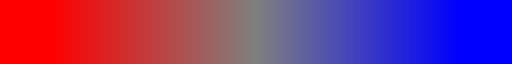

In [63]:
custom_seismic()

In [ ]:
# for every edge in the graph, calculate the correlation between the abundances of the two species
def get_correlation_edges(graph, abundances):
    correlations_edges = []
    for edge in graph.edges:
        species1 = species_index_T[edge[0]]
        species2 = species_index_T[edge[1]]
        abundance1 = abundances[species1]['y']
        abundance2 = abundances[species2]['y']
        correlation = np.corrcoef(abundance1, abundance2)[0, 1]
        correlations_edges.append(correlation)
    correlation_edges = np.array(correlations_edges)
    return correlation_edges

def get_edge_colors_and_widths(graph : nx.DiGraph, abundances, p_values):

    weight_edges = get_correlation_edges(graph, abundances)
    # used for coloring the edges: blue if positive correlation, red if negative
    def get_edge_color(correlation):
        if correlation > 0: return 'blue'
        else: return 'red'
    edge_colors = [get_edge_color(correlation) for correlation in weight_edges]
    edge_colors = [custom_seismic()((correlation+1) * 0.5) for correlation in weight_edges]
    edge_widths = []
    for edge in graph.edges:
        p_value = p_values[edge[0], edge[1]]
        # edge_widths.append(1 / (p_value + 0.01)**(0.25))
        edge_widths.append()
    edge_widths = np.array(edge_widths)
    return edge_colors, edge_widths

In [23]:
# add many graphs together as one
big_graph = nx.DiGraph()
for idx, graph in enumerate(graphs):
    big_graph = nx.compose(big_graph, graph)

In [25]:
big_pos, big_colors, big_state, bi_widths, big_color_community_index = SFDP_layout(big_graph)


<VertexPropertyMap object with value type 'int64_t', for Graph 0x7f5349f9b350, at 0x7f5346b64bb0>


<VertexPropertyMap object with value type 'int64_t', for Graph 0x7f536271be30, at 0x7f53619460b0>


KeyError: 0

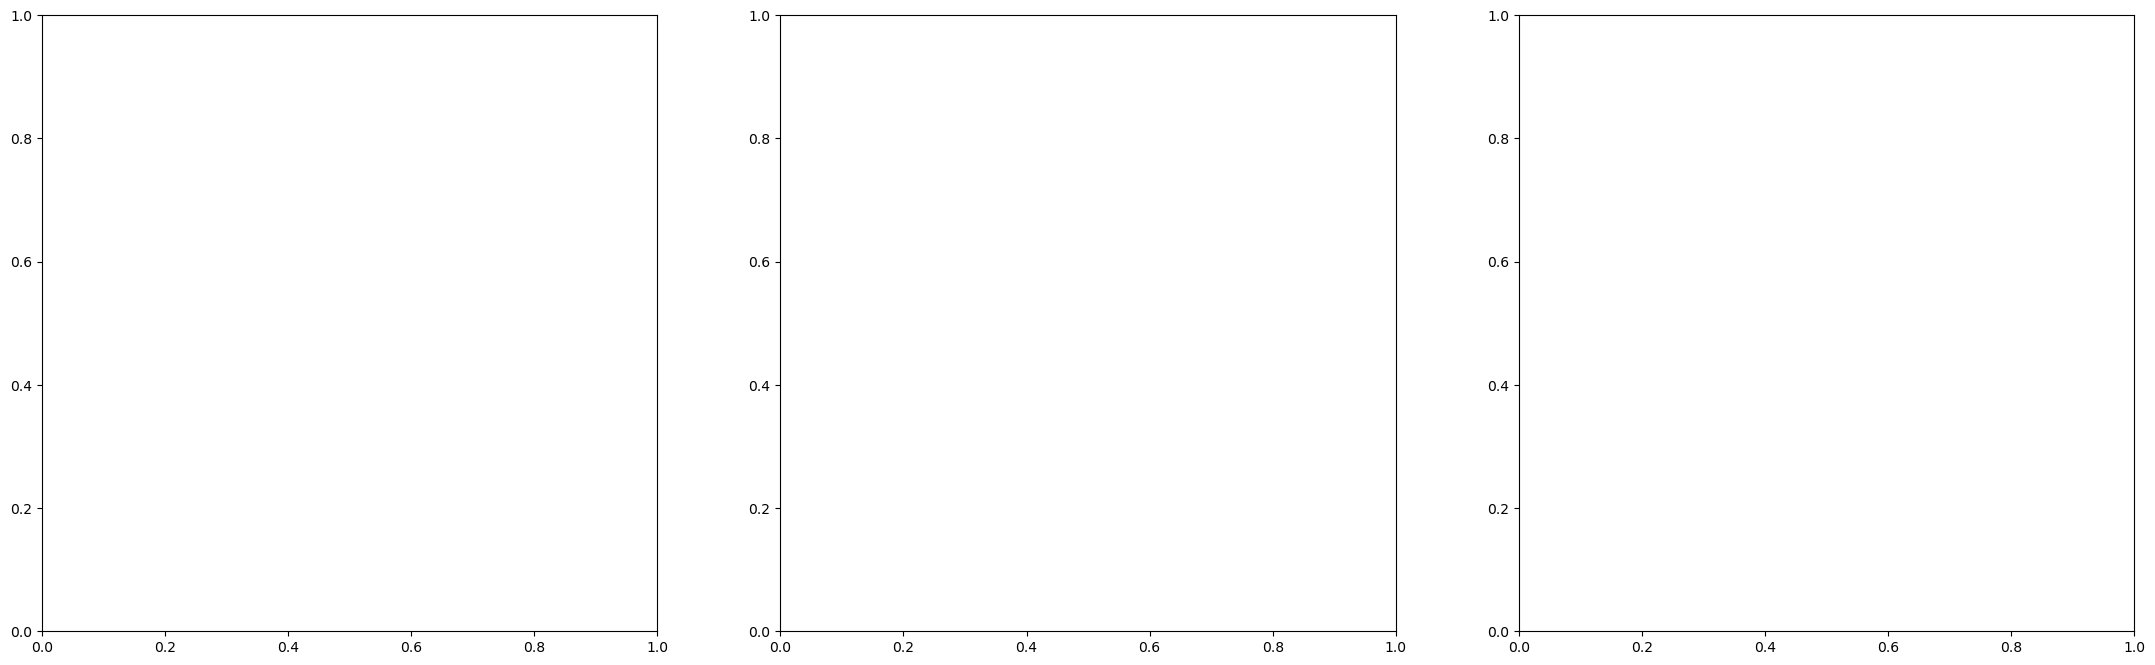

In [ ]:
import iplotx as ipx

# select graph for visualization
fig, axes = plt.subplots(1,3, figsize=(27,8))

# fig, axes = plt.subplots(1,2, figsize=(24,24))

for idx, graph_original in enumerate(graphs):
    (start, end) = windows[idx]
    graph = graph_original.copy()
    # remove nodes that have abundance of 0 in the current window
    nodes_to_delete = set()
    for node in graph.nodes():
        if abundances[species_index_T_non_aq[node]]['y'][start:end].sum() == 0:
            nodes_to_delete.add(node)

        # remove nodes that are not connected also
        if graph.degree(node) == 0:
            nodes_to_delete.add(node)
    
    graph.remove_nodes_from(nodes_to_delete)
    # remove the nodes from species_index_T_non_aq
    species_index_T_non_aq_abundances = {k: v for k, v in species_index_T_non_aq.items() if k not in nodes_to_delete}

    ax = axes.flatten()[idx]
    granger_causality_p_values = granger_causalities_p_values[idx]


    pos, colors, state, edge_widths, color_community_index = SFDP_layout(graph)
    pos = big_pos # use the position from the big graph to have the same layout for all windows

    

    #  ___________________  IPLOTX GROPUS PLOTTING ___________________
    # layout = pd.DataFrame.from_dict(pos, orient="index", columns=["x", "y"])
    custom_partition, custom_community_index, custom_community_index_T = get_functional_categories(database)
    custom_partition_idx = defaultdict(set)
    for node in graph.nodes():
        custom_partition_idx[custom_partition[species_index_T_non_aq[node]]].add(node)
    # now for the colors, color_community_index has the color for each community (by name, gotta map it to the index)
    # make grouping_facecolor_ipx a list in the order of the custom_partition_idx keys
    grouping_facecolor_ipx = {custom_community_index[community]:color for community, color in color_community_index.items()}
    grouping_facecolor_ipx = [grouping_facecolor_ipx[community] for community in custom_partition_idx.keys()]
    ipx.network(
        grouping=custom_partition_idx,
        layout=pos,                   # pass your dict of positions
        ax=ax,
        grouping_facecolor=grouping_facecolor_ipx,
        grouping_edgecolor="black",
        grouping_linewidth=2,
        grouping_vertexpadding=20,
        zorder=-1,                    # draw underneath your nodes
    ) # ___________________  ____________________  ___________________

    dict_abundances = {x:abundances[x]['y'].sum() for x in abundances.columns}
    sizes = [dict_abundances[species_index_T_non_aq[x]] for x in graph.nodes]

    # edge_colors, edge_widths = get_edge_colors_and_widths(graph, abundances, granger_causality_p_values)
    edge_colors = [granger_causalities[idx][u,v] for u, v in graph.edges()]
    edge_colors = [custom_seismic()((causality+1)/2) for causality in edge_colors]


    # size of the abundances
    # nx.draw_networkx_nodes(graph, ax = ax, node_size=[np.sqrt(size)*150 for size in sizes], node_color='grey', pos=pos, edgecolors='black', linewidths=1, alpha=1)
    # constant size and color of the group
    nx.draw_networkx_nodes(graph, ax = ax, node_size=400, node_color=colors, pos=pos, edgecolors='black', linewidths=1, alpha=1)

    nx.draw_networkx_edges(graph, ax = ax, alpha = 0.5, pos=pos, width=1.7, edge_color = edge_colors, connectionstyle='arc3,rad=0.1') #edge_color=edge_colors)

    if False: # add labels with white outline
        texts = nx.draw_networkx_labels(graph, ax = ax, font_size=10, labels=species_index_T_non_aq_abundances,
                                pos=pos, font_color='black', font_family='sans-serif');
        for text in texts.values():
            text.set_path_effects([path_effects.Stroke(linewidth=1.3, foreground='white'),
                            path_effects.Normal()])
            

    ax_x_lim = [min([big_pos[node][0] for node in big_pos]), max([big_pos[node][0] for node in big_pos])]
    ax_y_lim = [min([big_pos[node][1] for node in big_pos]), max([big_pos[node][1] for node in big_pos])]
    # set limits to a square
    width = (ax_x_lim[1] - ax_x_lim[0])
    height = (ax_y_lim[1] - ax_y_lim[0])
    width = height if height > width else width # use this for the square plot
    center = [ax_x_lim[0] + width/2, ax_y_lim[0] + height/2]
    zoom_out = 1.1
    
    ax.set_ylim(center[1] - zoom_out * width/2, center[1] + zoom_out * width/2)
    ax.set_xlim(center[0] - zoom_out * width/2, center[0] + zoom_out * width/2)

    # make a legend for the colors of the nodes groups
from matplotlib.lines import Line2D
if database == 'basa':
    legend_elements = [Line2D([0], [0], marker='o', color=color, label=community,
                        markerfacecolor=color, markersize=12) for community, color in color_community_index.items()]
    fig.legend(handles=legend_elements, fontsize=14, title='Community', title_fontsize=16,
           bbox_to_anchor=(0.5, -0.05), loc='lower center', ncol=4, framealpha=1)
for ax in axes:
    # put the square around
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_edgecolor('black')
        spine.set_linewidth(2)

In [32]:
# fig.savefig(f'{results}/conditional_gc_networks/fire_windows/conditional_gc_networks.png', dpi=200, bbox_inches='tight')
fig.savefig(f'./plots-tests/gc_networks_basa_partition.png', dpi=200, bbox_inches='tight')

In [26]:
# save fig to pickle
import pickle
with open(f'{results}/conditional_gc_networks/fire_windows/gc_networks.pickle', 'wb') as f:
    pickle.dump(fig, f)
# save the axes to pickle
with open(f'{results}/conditional_gc_networks/fire_windows/gc_networks_axes.pickle', 'wb') as f:
    pickle.dump(axes, f)

In [63]:
# calculate modularity of the partition

custom_partition, custom_community_index, custom_community_index_T = get_functional_categories(database)
for idx, graph in enumerate(graphs):

    network = graph.copy()
    custom_communities = [set([node for node in network.nodes() if custom_partition[species_index_T_non_aq[node]] == community]) for community in custom_community_index.values()]
    
    igraph_graph = ig.Graph.from_networkx(network)
    leiden_partition = la.find_partition(igraph_graph, la.ModularityVertexPartition, weights=None);

    leiden_communities = []
    for i, community in enumerate(leiden_partition):
        leiden_community = set()
        for node in community:
            # [vlist[igraph_graph.vs[node]['_nx_name']]] = i
            leiden_community.add(igraph_graph.vs[node]['_nx_name'])
        leiden_communities.append(leiden_community)


    leiden_modularity = nx.algorithms.community.quality.modularity(network,
        communities=leiden_communities,
        weight=None)
    
    custom_modularity = nx.algorithms.community.quality.modularity(network,
        communities=custom_communities,
        weight=None)
    
    print(leiden_modularity, custom_modularity)

0.3632770391663672 0.014263619178553002
0.42919667590027705 -0.016869806094182815
0.431158709930399 -0.048965787667875675


In [36]:
from itertools import combinations

def is_balanced_triangle(edge_signs):
    product = edge_signs[0] * edge_signs[1] * edge_signs[2]
    return product > 0  # +1 (balanced) if positive product

def calculate_balance(graph):
    triangles = [nodes for nodes in combinations(graph.nodes, 3)
                 if graph.has_edge(nodes[0], nodes[1]) and
                    graph.has_edge(nodes[0], nodes[2]) and
                    graph.has_edge(nodes[1], nodes[2])]
    balanced_count = 0

    for u, v, w in triangles:
        edge_signs = [
            graph[u][v]['sign'],
            graph[u][w]['sign'],
            graph[v][w]['sign']
        ]
        if is_balanced_triangle(edge_signs):
            balanced_count += 1

    total_triangles = len(triangles)
    if total_triangles == 0:
        return 1.0, 0  # trivially balanced if no triangles

    return (balanced_count/total_triangles,total_triangles)

for graph in graphs:
    for u, v in graph.edges():
        # Assign a sign to each edge based on the causality value
        sign = 1 if granger_causalities[idx][u, v] > 0 else -1
        graph[u][v]['sign'] = sign

    balance, triangles = calculate_balance(graph)
    print(f"Balance ratio: {balance:.2f}, Total triangles: {triangles}")

Balance ratio: 0.47, Total triangles: 17
Balance ratio: 0.30, Total triangles: 10
Balance ratio: 1.00, Total triangles: 2
